# Long

In [2]:
from pathlib import Path
import json
import pandas as pd

ROOTS = [
    Path(r"C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_llm_outputs"),
    Path(r"C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_llm_outputs"),
    Path(r"C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_llm_outputs_querytime_top5"),
    Path(r"C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs"),
    Path(r"C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_final_hybrid_outputs"),
    Path(r"C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_routed_final_outputs"),
    Path(r"C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_retrieval_ablation_outputs"),
]

KEY_PATTERNS = [
    "summary",
    "by_task",
    "by_difficulty",
    "relaxed",
    "failure",
    "ablation",
    "metrics",
]

def human_size(n):
    n = float(n)
    units = ["B", "KB", "MB", "GB"]
    i = 0
    while n >= 1024 and i < len(units) - 1:
        n /= 1024
        i += 1
    return f"{n:.1f} {units[i]}"

def is_key_file(p: Path):
    name = p.name.lower()
    return (
        p.suffix.lower() in {".csv", ".json"}
        and any(k in name for k in KEY_PATTERNS)
    )

for root in ROOTS:
    print("\n" + "=" * 140)
    print("FOLDER:", root)
    print("=" * 140)

    if not root.exists():
        print("MISSING")
        continue

    files = sorted([p for p in root.rglob("*") if p.is_file() and is_key_file(p)])

    if not files:
        print("No key summary/metrics files found.")
        continue

    for p in files:
        rel = p.relative_to(root)
        print("\n" + "-" * 120)
        print("FILE:", rel)
        print("SIZE:", human_size(p.stat().st_size))

        if p.suffix.lower() == ".csv":
            try:
                df = pd.read_csv(p)
                print("SHAPE:", df.shape)
                print("COLUMNS:", list(df.columns))
                print("HEAD:")
                print(df.head(5).to_string(index=False))
            except Exception as e:
                print("CSV READ ERROR:", e)

        elif p.suffix.lower() == ".json":
            try:
                with p.open("r", encoding="utf-8") as f:
                    obj = json.load(f)

                if isinstance(obj, dict):
                    print("JSON KEYS:", list(obj.keys())[:50])
                    print("JSON PREVIEW:")
                    print(json.dumps(obj, ensure_ascii=False, indent=2)[:1500])
                elif isinstance(obj, list):
                    print("JSON LIST LEN:", len(obj))
                    print("FIRST ITEM:")
                    print(json.dumps(obj[0], ensure_ascii=False, indent=2)[:1500] if obj else "EMPTY")
                else:
                    print("JSON TYPE:", type(obj).__name__)
                    print(str(obj)[:1500])
            except Exception as e:
                print("JSON READ ERROR:", e)


FOLDER: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_llm_outputs

------------------------------------------------------------------------------------------------------------------------
FILE: failure_analysis\all_failure_categories.csv
SIZE: 3.0 KB
SHAPE: (35, 5)
COLUMNS: ['mode', 'failure_category', 'count', 'rate_among_strict_failures', 'rate_among_all']
HEAD:
        mode                        failure_category  count  rate_among_strict_failures  rate_among_all
full_history     false_negative_format_or_paraphrase    316                    0.831579        0.380723
full_history                   yes_no_semantic_error     33                    0.086842        0.039759
full_history answer_error_despite_some_gold_evidence     10                    0.026316        0.012048
full_history               duration_arithmetic_error      9                    0.023684        0.010843
full_history                date_missing_or_unparsed      6                    0.015789        0.007229

In [3]:
from pathlib import Path
import pandas as pd
import json


# ============================================================
# PATHS
# ============================================================

ROOT = Path(r"C:\Users\ivan\WORK\workshops\EMNLP\TimeBound")

SHORT_DIR = ROOT / "timebound_llm_outputs"
LONG_DIR = ROOT / "timebound_long_llm_outputs"
QUERYTIME_TOP5_DIR = ROOT / "timebound_long_llm_outputs_querytime_top5"
GRID_DIR = ROOT / "timebound_long_ablation_grid_outputs"
HYBRID_DIR = ROOT / "timebound_long_final_hybrid_outputs"
ROUTED_DIR = ROOT / "timebound_long_routed_final_outputs"
RETRIEVAL_ABL_DIR = ROOT / "timebound_retrieval_ablation_outputs"

OUT_DIR = ROOT / "paper_main_tables"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# HELPERS
# ============================================================

def read_csv_safe(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"Missing: {path}")
        return pd.DataFrame()
    return pd.read_csv(path)


def round_numeric(df: pd.DataFrame, ndigits: int = 3) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        if pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].round(ndigits)
    return out


def save_table(df: pd.DataFrame, name: str) -> Path:
    path = OUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False, encoding="utf-8")
    print(f"Saved: {path} | shape={df.shape}")
    return path


def mode_label(x: str) -> str:
    mapping = {
        "full_history": "Full history",
        "semantic_rag": "Semantic RAG",
        "timebound_rag": "TimeBound-RAG",
        "oracle_evidence": "Oracle evidence",
        "timebound_hybrid": "Hybrid TimeBound",
        "timebound_routed": "Routed TimeBound",
    }
    return mapping.get(str(x), str(x))


# ============================================================
# TABLE 1: MAIN TIMEBOUND-LONG RESULTS
# Source:
#   LONG_DIR/llm_summary.csv
#   LONG_DIR/failure_analysis/relaxed_eval_summary.csv
# ============================================================

llm_summary = read_csv_safe(LONG_DIR / "llm_summary.csv")
relaxed_summary = read_csv_safe(LONG_DIR / "failure_analysis" / "relaxed_eval_summary.csv")

if not llm_summary.empty and not relaxed_summary.empty:
    table1 = llm_summary.merge(
        relaxed_summary[
            [
                "mode",
                "strict_accuracy",
                "relaxed_accuracy",
                "false_negative_recovered",
                "false_negative_recovered_rate",
            ]
        ],
        on="mode",
        how="left",
    )

    table1 = table1[
        [
            "mode",
            "model",
            "n_examples",
            "llm_success_rate",
            "answer_accuracy",
            "strict_accuracy",
            "relaxed_accuracy",
            "evidence_precision",
            "evidence_recall",
            "evidence_f1",
            "contradiction_rate",
            "top1_context_hit_rate",
            "gold_in_context_rate",
            "false_negative_recovered",
            "false_negative_recovered_rate",
            "top_k",
        ]
    ]

    table1.insert(1, "method", table1["mode"].map(mode_label))
    table1 = round_numeric(table1)
    save_table(table1, "table1_long_main_results")
else:
    table1 = pd.DataFrame()


# ============================================================
# TABLE 2: TIMEBOUND-LONG BY TASK
# Keep key modes only: semantic_rag, timebound_rag, oracle_evidence
# Source:
#   LONG_DIR/failure_analysis/relaxed_by_task.csv
# ============================================================

relaxed_by_task = read_csv_safe(LONG_DIR / "failure_analysis" / "relaxed_by_task.csv")

KEY_MODES = ["semantic_rag", "timebound_rag", "oracle_evidence"]

if not relaxed_by_task.empty:
    t2 = relaxed_by_task[relaxed_by_task["mode"].isin(KEY_MODES)].copy()
    t2["method"] = t2["mode"].map(mode_label)

    # Wide table for paper readability
    t2_wide = t2.pivot_table(
        index=["task_type", "n_examples"],
        columns="method",
        values=["strict_accuracy", "relaxed_accuracy", "evidence_f1", "contradiction_rate"],
        aggfunc="first",
    )

    t2_wide.columns = [f"{metric}__{method}" for metric, method in t2_wide.columns]
    t2_wide = t2_wide.reset_index()

    # Useful deltas
    if "relaxed_accuracy__TimeBound-RAG" in t2_wide.columns and "relaxed_accuracy__Semantic RAG" in t2_wide.columns:
        t2_wide["delta_relaxed_TimeBound_minus_Semantic"] = (
            t2_wide["relaxed_accuracy__TimeBound-RAG"]
            - t2_wide["relaxed_accuracy__Semantic RAG"]
        )

    if "evidence_f1__TimeBound-RAG" in t2_wide.columns and "evidence_f1__Semantic RAG" in t2_wide.columns:
        t2_wide["delta_evidence_f1_TimeBound_minus_Semantic"] = (
            t2_wide["evidence_f1__TimeBound-RAG"]
            - t2_wide["evidence_f1__Semantic RAG"]
        )

    t2_wide = round_numeric(t2_wide)
    save_table(t2_wide, "table2_long_by_task_key_modes")
else:
    t2_wide = pd.DataFrame()


# ============================================================
# TABLE 3: ABLATION VARIANTS FOR MAIN BODY
# Compact comparison:
#   Long baseline top-k=3 TimeBound-RAG
#   Query-time/top-k=5
#   Hybrid
#   Routed
# ============================================================

rows = []

# Original TimeBound-RAG top-k=3 from long
if not llm_summary.empty and not relaxed_summary.empty:
    base = llm_summary[llm_summary["mode"] == "timebound_rag"].copy()
    base_rel = relaxed_summary[relaxed_summary["mode"] == "timebound_rag"].copy()

    if len(base) and len(base_rel):
        b = base.iloc[0].to_dict()
        br = base_rel.iloc[0].to_dict()

        rows.append({
            "variant": "TimeBound-RAG, top-k=3",
            "source": "timebound_long_llm_outputs",
            "n_examples": b.get("n_examples"),
            "strict_accuracy": br.get("strict_accuracy"),
            "relaxed_accuracy": br.get("relaxed_accuracy"),
            "evidence_precision": b.get("evidence_precision"),
            "evidence_recall": b.get("evidence_recall"),
            "evidence_f1": b.get("evidence_f1"),
            "contradiction_rate": b.get("contradiction_rate"),
            "top1_context_hit_rate": b.get("top1_context_hit_rate"),
            "gold_in_context_rate": b.get("gold_in_context_rate"),
            "top_k": b.get("top_k"),
            "note": "Original TimeBound-RAG on Long.",
        })

# Query-time/top-k=5
qt = read_csv_safe(QUERYTIME_TOP5_DIR / "llm_summary.csv")
if not qt.empty:
    q = qt.iloc[0].to_dict()
    rows.append({
        "variant": "Query-time TimeBound-RAG, top-k=5",
        "source": "timebound_long_llm_outputs_querytime_top5",
        "n_examples": q.get("n_examples"),
        "strict_accuracy": q.get("answer_accuracy"),
        "relaxed_accuracy": None,
        "evidence_precision": q.get("evidence_precision"),
        "evidence_recall": q.get("evidence_recall"),
        "evidence_f1": q.get("evidence_f1"),
        "contradiction_rate": q.get("contradiction_rate"),
        "top1_context_hit_rate": q.get("top1_context_hit_rate"),
        "gold_in_context_rate": q.get("gold_in_context_rate"),
        "top_k": q.get("top_k"),
        "note": "Top-k=5 query-time variant; useful mainly as negative/sensitivity result.",
    })

# Hybrid
hyb = read_csv_safe(HYBRID_DIR / "summary.csv")
if not hyb.empty:
    h = hyb.iloc[0].to_dict()
    rows.append({
        "variant": "Hybrid TimeBound",
        "source": "timebound_long_final_hybrid_outputs",
        "n_examples": h.get("n_examples"),
        "strict_accuracy": h.get("strict_accuracy"),
        "relaxed_accuracy": h.get("relaxed_accuracy"),
        "evidence_precision": h.get("evidence_precision"),
        "evidence_recall": h.get("evidence_recall"),
        "evidence_f1": h.get("evidence_f1"),
        "contradiction_rate": h.get("contradiction_rate"),
        "top1_context_hit_rate": h.get("top1_context_hit_rate"),
        "gold_in_context_rate": h.get("gold_in_context_rate"),
        "top_k": h.get("top_k"),
        "note": "Improves some retrospective validity cases but hurts update-resolution tasks.",
    })

# Routed
routed = read_csv_safe(ROUTED_DIR / "summary.csv")
if not routed.empty:
    r = routed.iloc[0].to_dict()
    rows.append({
        "variant": "Routed TimeBound",
        "source": "timebound_long_routed_final_outputs",
        "n_examples": r.get("n_examples"),
        "strict_accuracy": r.get("strict_accuracy"),
        "relaxed_accuracy": r.get("relaxed_accuracy"),
        "evidence_precision": r.get("evidence_precision"),
        "evidence_recall": r.get("evidence_recall"),
        "evidence_f1": r.get("evidence_f1"),
        "contradiction_rate": r.get("contradiction_rate"),
        "top1_context_hit_rate": r.get("top1_context_hit_rate"),
        "gold_in_context_rate": r.get("gold_in_context_rate"),
        "top_k": None,
        "note": "Manual routing did not outperform the original TimeBound-RAG.",
    })

table3 = round_numeric(pd.DataFrame(rows))
save_table(table3, "table3_ablation_variants")


# ============================================================
# TABLE 4: FAILURE CATEGORIES, COMPACT
# Source:
#   LONG_DIR/failure_analysis/all_failure_categories.csv
# Keep top 5 per mode by rate_among_all
# ============================================================

fail_all = read_csv_safe(LONG_DIR / "failure_analysis" / "all_failure_categories.csv")

if not fail_all.empty:
    table4 = (
        fail_all
        .sort_values(["mode", "rate_among_all"], ascending=[True, False])
        .groupby("mode")
        .head(5)
        .copy()
    )

    table4["method"] = table4["mode"].map(mode_label)
    table4 = table4[
        [
            "mode",
            "method",
            "failure_category",
            "count",
            "rate_among_strict_failures",
            "rate_among_all",
        ]
    ]
    table4 = round_numeric(table4)
    save_table(table4, "table4_failure_categories_top")
else:
    table4 = pd.DataFrame()


# ============================================================
# TABLE 5: RETRIEVAL-ONLY ABLATION COMPACT
# Source:
#   timebound_retrieval_ablation_outputs/ablation_summary.csv
# ============================================================

retrieval_abl = read_csv_safe(RETRIEVAL_ABL_DIR / "ablation_summary.csv")

if not retrieval_abl.empty:
    table5 = retrieval_abl[
        [
            "ablation",
            "n_examples",
            "answer_accuracy",
            "evidence_precision",
            "evidence_recall",
            "evidence_f1",
            "top1_evidence_hit_rate",
            "gold_in_topk_rate",
            "invalid_evidence_rate",
            "contradiction_rate",
            "alpha",
            "beta",
            "gamma",
            "top_k",
            "description",
        ]
    ].copy()

    table5 = round_numeric(table5)
    save_table(table5, "table5_retrieval_ablation_compact")
else:
    table5 = pd.DataFrame()


# ============================================================
# TABLE 6: SHORT VS LONG, OPTIONAL MAIN/PRELIMINARY
# Useful if you want to show that Long is much harder.
# Sources:
#   SHORT_DIR/failure_analysis/relaxed_eval_summary.csv
#   LONG_DIR/failure_analysis/relaxed_eval_summary.csv
# ============================================================

short_relaxed = read_csv_safe(SHORT_DIR / "failure_analysis" / "relaxed_eval_summary.csv")
long_relaxed = read_csv_safe(LONG_DIR / "failure_analysis" / "relaxed_eval_summary.csv")

rows = []

if not short_relaxed.empty:
    x = short_relaxed.copy()
    x.insert(0, "setting", "Short")
    rows.append(x)

if not long_relaxed.empty:
    x = long_relaxed.copy()
    x.insert(0, "setting", "Long")
    rows.append(x)

if rows:
    table6 = pd.concat(rows, ignore_index=True)
    table6["method"] = table6["mode"].map(mode_label)
    table6 = table6[
        [
            "setting",
            "mode",
            "method",
            "n_examples",
            "strict_accuracy",
            "relaxed_accuracy",
            "strict_bad",
            "relaxed_bad",
            "false_negative_recovered",
            "false_negative_recovered_rate",
        ]
    ]
    table6 = round_numeric(table6)
    save_table(table6, "table6_short_vs_long_relaxed")
else:
    table6 = pd.DataFrame()


# ============================================================
# EXPORT ONE EXCEL WORKBOOK
# ============================================================

xlsx_path = OUT_DIR / "paper_main_body_tables.xlsx"

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    if not table1.empty:
        table1.to_excel(writer, sheet_name="T1_long_main", index=False)

    if not t2_wide.empty:
        t2_wide.to_excel(writer, sheet_name="T2_by_task", index=False)

    if not table3.empty:
        table3.to_excel(writer, sheet_name="T3_ablation_variants", index=False)

    if not table4.empty:
        table4.to_excel(writer, sheet_name="T4_failure_top", index=False)

    if not table5.empty:
        table5.to_excel(writer, sheet_name="T5_retrieval_ablation", index=False)

    if not table6.empty:
        table6.to_excel(writer, sheet_name="T6_short_vs_long", index=False)

print("\n" + "=" * 100)
print("DONE")
print("=" * 100)
print("Output folder:", OUT_DIR)
print("Excel workbook:", xlsx_path)

Saved: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\paper_main_tables\table1_long_main_results.csv | shape=(4, 17)
Saved: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\paper_main_tables\table2_long_by_task_key_modes.csv | shape=(8, 16)
Saved: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\paper_main_tables\table3_ablation_variants.csv | shape=(4, 13)
Saved: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\paper_main_tables\table4_failure_categories_top.csv | shape=(18, 6)
Saved: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\paper_main_tables\table5_retrieval_ablation_compact.csv | shape=(5, 15)
Saved: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\paper_main_tables\table6_short_vs_long_relaxed.csv | shape=(8, 10)

DONE
Output folder: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\paper_main_tables
Excel workbook: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\paper_main_tables\paper_main_body_tables.xlsx


Loaded: (243, 15)
Columns: ['config_name', 'policy', 'top_k', 'alpha', 'beta', 'gamma', 'n_examples', 'evidence_precision', 'evidence_recall', 'evidence_f1', 'top1_hit', 'gold_in_topk', 'invalid_top1', 'contradiction_like', 'rank_score']
Policies: ['hybrid', 'original', 'querytime']
Filtered: (81, 15)


,config_name,policy,top_k,alpha,beta,gamma,n_examples,evidence_precision,evidence_recall,evidence_f1,top1_hit,gold_in_topk,invalid_top1,contradiction_like,rank_score
0,hybrid_k3_a0.6_b0.3_g0.3,hybrid,3,0.6,0.3,0.3,100,0.343333,0.455,0.385,0.74,0.78,0.1,0.01,0.905
1,hybrid_k3_a0.5_b0.3_g0.3,hybrid,3,0.5,0.3,0.3,100,0.343333,0.455,0.385,0.74,0.78,0.1,0.01,0.905
2,hybrid_k3_a0.6_b0.4_g0.3,hybrid,3,0.6,0.4,0.3,100,0.343333,0.455,0.385,0.74,0.78,0.1,0.01,0.905
3,hybrid_k3_a0.7_b0.4_g0.3,hybrid,3,0.7,0.4,0.3,100,0.343333,0.455,0.385,0.74,0.78,0.1,0.01,0.905
4,hybrid_k3_a0.6_b0.5_g0.3,hybrid,3,0.6,0.5,0.3,100,0.340000,0.450,0.381,0.74,0.78,0.1,0.01,0.901


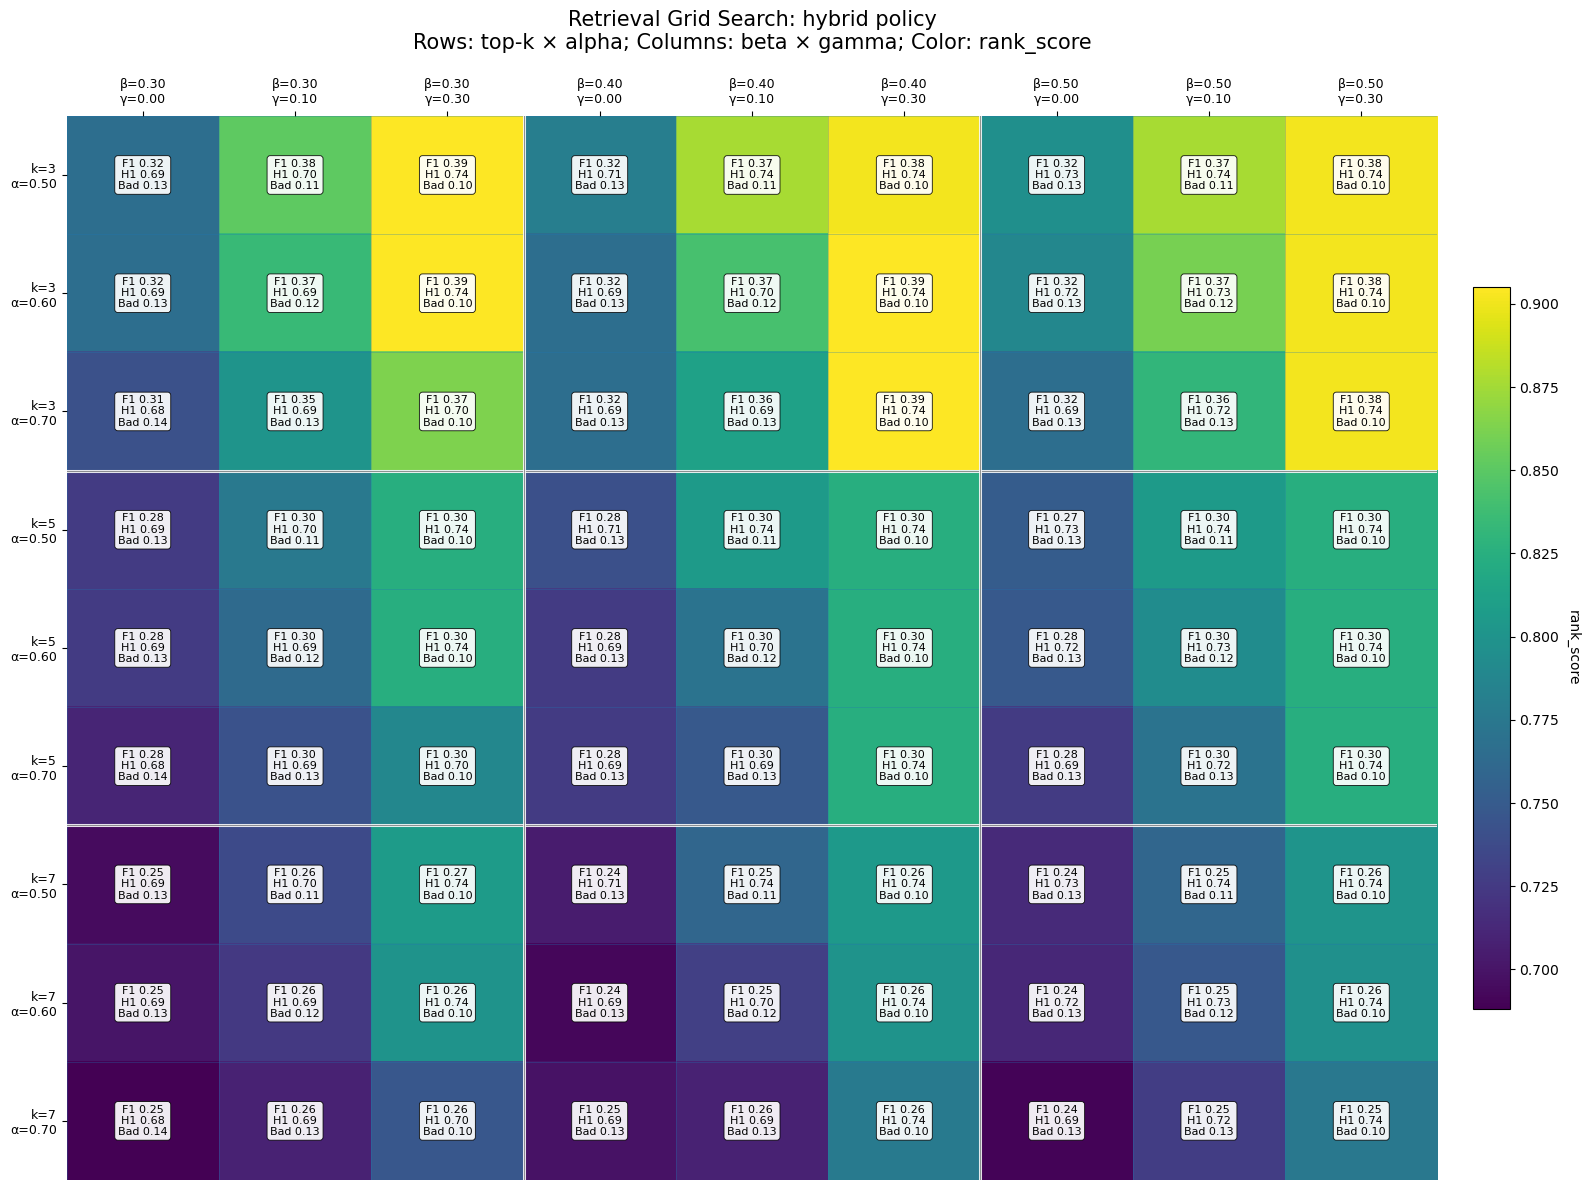

Saved PNG: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\grid_visualizations\retrieval_grid_9x9_hybrid_rank_score.png
Saved PDF: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\grid_visualizations\retrieval_grid_9x9_hybrid_rank_score.pdf


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# ============================================================
# CONFIG
# ============================================================

INPUT_CSV = Path(r"C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\retrieval_grid_summary.csv")

OUT_DIR = INPUT_CSV.parent / "grid_visualizations"
OUT_DIR.mkdir(parents=True, exist_ok=True)

POLICY = "hybrid"   # hybrid / semantic / temporal / whatever exists in your file

DEFAULT_TOP_KS = [3, 5, 7]
DEFAULT_ALPHAS = [0.50, 0.60, 0.70]
DEFAULT_BETAS = [0.30, 0.40, 0.50]
DEFAULT_GAMMAS = [0.00, 0.10, 0.30]

# Cell background color metric
COLOR_METRIC = "rank_score"

# Three values printed inside each cell
CELL_METRICS = [
    ("F1", "evidence_f1"),
    ("H1", "top1_hit"),
    ("Bad", "invalid_top1"),
]

# Output names
OUT_PNG = OUT_DIR / f"retrieval_grid_9x9_{POLICY}_{COLOR_METRIC}.png"
OUT_PDF = OUT_DIR / f"retrieval_grid_9x9_{POLICY}_{COLOR_METRIC}.pdf"


# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(INPUT_CSV)

print("Loaded:", df.shape)
print("Columns:", list(df.columns))
print("Policies:", sorted(df["policy"].dropna().unique()) if "policy" in df.columns else "NO policy column")

if "policy" in df.columns:
    d = df[df["policy"] == POLICY].copy()
else:
    d = df.copy()

if d.empty:
    raise ValueError(f"No rows for POLICY={POLICY}")

# Round params to avoid float matching issues
for col in ["alpha", "beta", "gamma"]:
    if col in d.columns:
        d[col] = d[col].astype(float).round(2)

d["top_k"] = d["top_k"].astype(int)

required_cols = ["top_k", "alpha", "beta", "gamma", COLOR_METRIC] + [m for _, m in CELL_METRICS]
missing = [c for c in required_cols if c not in d.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

print("Filtered:", d.shape)
display(d.head())


# ============================================================
# BUILD 9x9 GRID
# Rows:    top_k x alpha
# Columns: beta x gamma
# ============================================================

row_keys = [(k, a) for k in DEFAULT_TOP_KS for a in DEFAULT_ALPHAS]
col_keys = [(b, g) for b in DEFAULT_BETAS for g in DEFAULT_GAMMAS]

Z = np.full((len(row_keys), len(col_keys)), np.nan)
cell_text = [["" for _ in col_keys] for __ in row_keys]

lookup = {}

for _, r in d.iterrows():
    key = (
        int(r["top_k"]),
        round(float(r["alpha"]), 2),
        round(float(r["beta"]), 2),
        round(float(r["gamma"]), 2),
    )
    lookup[key] = r

for i, (top_k, alpha) in enumerate(row_keys):
    for j, (beta, gamma) in enumerate(col_keys):
        key = (top_k, alpha, beta, gamma)
        if key not in lookup:
            continue

        r = lookup[key]
        Z[i, j] = float(r[COLOR_METRIC])

        lines = []
        for short_name, metric_col in CELL_METRICS:
            val = float(r[metric_col])
            lines.append(f"{short_name} {val:.2f}")

        cell_text[i][j] = "\n".join(lines)


# ============================================================
# PLOT
# ============================================================

fig_w = 16
fig_h = 12

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(Z, cmap="viridis", aspect="auto")

# Grid lines
for x in np.arange(-0.5, len(col_keys), 1):
    ax.axvline(x, linewidth=0.6, alpha=0.35)

for y in np.arange(-0.5, len(row_keys), 1):
    ax.axhline(y, linewidth=0.6, alpha=0.35)


# Axis ticks
ax.set_xticks(np.arange(len(col_keys)))
ax.set_yticks(np.arange(len(row_keys)))

xlabels = [f"β={b:.2f}\nγ={g:.2f}" for b, g in col_keys]
ylabels = [f"k={k}\nα={a:.2f}" for k, a in row_keys]

ax.set_xticklabels(xlabels, fontsize=9)
ax.set_yticklabels(ylabels, fontsize=9)

ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

ax.set_xlabel("")
ax.set_ylabel("")

# Section separators between top_k blocks and beta blocks
for y in [2.5, 5.5]:
    ax.axhline(y, linewidth=2.2, color="white", alpha=0.9)
    ax.axhline(y, linewidth=0.8, color="black", alpha=0.4)

for x in [2.5, 5.5]:
    ax.axvline(x, linewidth=2.2, color="white", alpha=0.9)
    ax.axvline(x, linewidth=0.8, color="black", alpha=0.4)


# Text in white bbox
for i in range(len(row_keys)):
    for j in range(len(col_keys)):
        if np.isnan(Z[i, j]):
            continue

        txt = cell_text[i][j]

        ax.text(
            j,
            i,
            txt,
            ha="center",
            va="center",
            fontsize=8,
            color="black",
            linespacing=1.15,
            bbox=dict(
                boxstyle="round,pad=0.28",
                facecolor="white",
                edgecolor="black",
                linewidth=0.6,
                alpha=0.92,
            ),
        )


# Title
ax.set_title(
    f"Retrieval Grid Search: {POLICY} policy\n"
    f"Rows: top-k × alpha; Columns: beta × gamma; Color: {COLOR_METRIC}",
    fontsize=15,
    pad=48,
)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.025)
cbar.set_label(COLOR_METRIC, rotation=270, labelpad=15)

# Clean spines
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")

plt.show()

print("Saved PNG:", OUT_PNG)
print("Saved PDF:", OUT_PDF)

Loaded: (81, 15)
                config_name  policy  top_k  alpha  beta  gamma  n_examples  \
0  hybrid_k3_a0.6_b0.3_g0.3  hybrid      3    0.6   0.3    0.3         100   
1  hybrid_k3_a0.5_b0.3_g0.3  hybrid      3    0.5   0.3    0.3         100   
2  hybrid_k3_a0.6_b0.4_g0.3  hybrid      3    0.6   0.4    0.3         100   
3  hybrid_k3_a0.7_b0.4_g0.3  hybrid      3    0.7   0.4    0.3         100   
4  hybrid_k3_a0.6_b0.5_g0.3  hybrid      3    0.6   0.5    0.3         100   

   evidence_precision  evidence_recall  evidence_f1  top1_hit  gold_in_topk  \
0            0.343333            0.455        0.385      0.74          0.78   
1            0.343333            0.455        0.385      0.74          0.78   
2            0.343333            0.455        0.385      0.74          0.78   
3            0.343333            0.455        0.385      0.74          0.78   
4            0.340000            0.450        0.381      0.74          0.78   

   invalid_top1  contradiction_like  ra

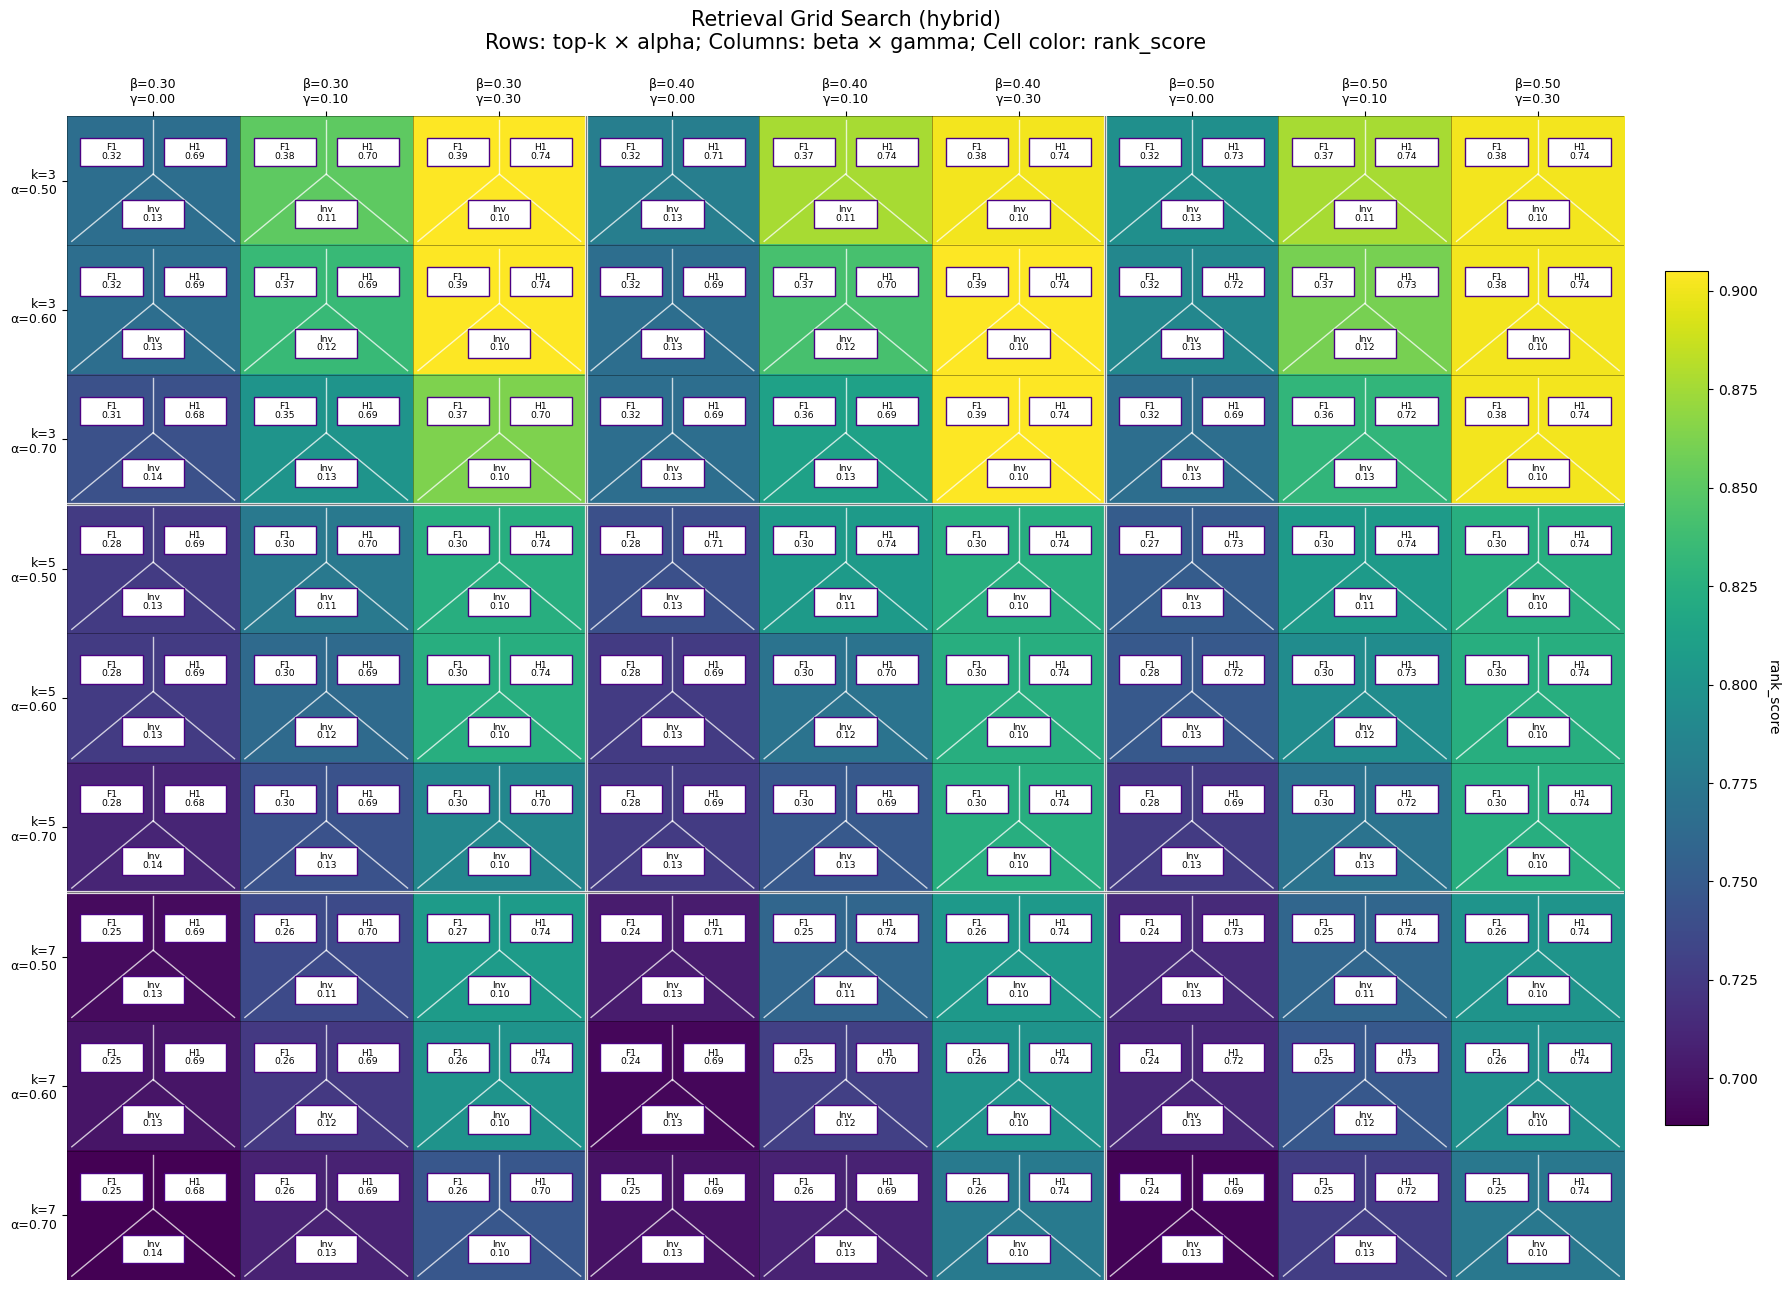

Saved PNG: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\grid_visualizations\retrieval_grid_9x9_subcells_hybrid_rank_score.png
Saved PDF: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\grid_visualizations\retrieval_grid_9x9_subcells_hybrid_rank_score.pdf


In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# ============================================================
# CONFIG
# ============================================================

INPUT_CSV = Path(
    r"C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\retrieval_grid_summary.csv"
)

OUT_DIR = INPUT_CSV.parent / "grid_visualizations"
OUT_DIR.mkdir(parents=True, exist_ok=True)

POLICY = "hybrid"

DEFAULT_TOP_KS = [3, 5, 7]
DEFAULT_ALPHAS = [0.50, 0.60, 0.70]
DEFAULT_BETAS = [0.30, 0.40, 0.50]
DEFAULT_GAMMAS = [0.00, 0.10, 0.30]

# Цвет всей ячейки
COLOR_METRIC = "rank_score"

# Три подячейки внутри каждой клетки
# label, column
SUBCELL_METRICS = [
    ("F1", "evidence_f1"),
    ("H1", "top1_hit"),
    ("Inv", "invalid_top1"),
]

OUT_PNG = OUT_DIR / f"retrieval_grid_9x9_subcells_{POLICY}_{COLOR_METRIC}.png"
OUT_PDF = OUT_DIR / f"retrieval_grid_9x9_subcells_{POLICY}_{COLOR_METRIC}.pdf"


# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(INPUT_CSV)

if "policy" in df.columns:
    d = df[df["policy"] == POLICY].copy()
else:
    d = df.copy()

if d.empty:
    raise ValueError(f"No rows for POLICY={POLICY}")

for col in ["alpha", "beta", "gamma"]:
    d[col] = d[col].astype(float).round(2)

d["top_k"] = d["top_k"].astype(int)

required = ["top_k", "alpha", "beta", "gamma", COLOR_METRIC] + [c for _, c in SUBCELL_METRICS]
missing = [c for c in required if c not in d.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

print("Loaded:", d.shape)
print(d.head())


# ============================================================
# BUILD GRID
# ============================================================

row_keys = [(k, a) for k in DEFAULT_TOP_KS for a in DEFAULT_ALPHAS]
col_keys = [(b, g) for b in DEFAULT_BETAS for g in DEFAULT_GAMMAS]

Z = np.full((len(row_keys), len(col_keys)), np.nan)
lookup = {}

for _, r in d.iterrows():
    key = (
        int(r["top_k"]),
        round(float(r["alpha"]), 2),
        round(float(r["beta"]), 2),
        round(float(r["gamma"]), 2),
    )
    lookup[key] = r

for i, (top_k, alpha) in enumerate(row_keys):
    for j, (beta, gamma) in enumerate(col_keys):
        key = (top_k, alpha, beta, gamma)

        if key not in lookup:
            continue

        Z[i, j] = float(lookup[key][COLOR_METRIC])


# ============================================================
# DRAW HELPERS
# ============================================================

def draw_subcell(ax, x, y, w, h, label, value, fontsize=6.6):
    """
    Draw one white boxed subcell inside a major heatmap cell.
    x, y are lower-left coordinates in data units.
    """
    rect = Rectangle(
        (x, y),
        w,
        h,
        facecolor="white",
        edgecolor="#4b0082",
        linewidth=1.0,
        zorder=5,
    )
    ax.add_patch(rect)

    txt = f"{label}\n{value:.2f}"

    ax.text(
        x + w / 2,
        y + h / 2,
        txt,
        ha="center",
        va="center",
        fontsize=fontsize,
        color="black",
        zorder=6,
        linespacing=0.95,
    )


def draw_cell_subdivision(ax, cx, cy):
    """
    Draw decorative internal division lines inside one heatmap cell.
    cx, cy = center of major cell.
    Cell spans [cx-0.5, cx+0.5], [cy-0.5, cy+0.5].
    """

    left = cx - 0.5
    right = cx + 0.5
    top = cy - 0.5
    bottom = cy + 0.5

    # vertical split in upper part
    ax.plot(
        [cx, cx],
        [top + 0.03, cy - 0.05],
        color="white",
        linewidth=1.0,
        alpha=0.75,
        zorder=4,
    )

    # lower wedge diagonals
    ax.plot(
        [left + 0.03, cx],
        [bottom - 0.03, cy - 0.05],
        color="white",
        linewidth=1.0,
        alpha=0.75,
        zorder=4,
    )

    ax.plot(
        [right - 0.03, cx],
        [bottom - 0.03, cy - 0.05],
        color="white",
        linewidth=1.0,
        alpha=0.75,
        zorder=4,
    )


def draw_three_subcells(ax, cx, cy, values):
    """
    Places three boxed subcells like in the sketch:
      top-left
      top-right
      bottom-center
    """

    # Major cell boundaries
    # cell center = (cx, cy), cell size = 1x1

    # Top-left box
    w = 0.36
    h = 0.22
    draw_subcell(
        ax=ax,
        x=cx - 0.42,
        y=cy - 0.33,
        w=w,
        h=h,
        label=values[0][0],
        value=values[0][1],
    )

    # Top-right box
    draw_subcell(
        ax=ax,
        x=cx + 0.06,
        y=cy - 0.33,
        w=w,
        h=h,
        label=values[1][0],
        value=values[1][1],
    )

    # Bottom-center box
    draw_subcell(
        ax=ax,
        x=cx - 0.18,
        y=cy + 0.15,
        w=w,
        h=h,
        label=values[2][0],
        value=values[2][1],
    )


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(18, 13))

im = ax.imshow(Z, cmap="viridis", aspect="auto")

# Major grid lines
for x in np.arange(-0.5, len(col_keys), 1):
    ax.axvline(x, linewidth=0.7, color="black", alpha=0.35, zorder=3)

for y in np.arange(-0.5, len(row_keys), 1):
    ax.axhline(y, linewidth=0.7, color="black", alpha=0.35, zorder=3)

# Strong separators between beta blocks and top_k blocks
for x in [2.5, 5.5]:
    ax.axvline(x, linewidth=2.3, color="white", alpha=0.9, zorder=4)
    ax.axvline(x, linewidth=0.9, color="black", alpha=0.45, zorder=4)

for y in [2.5, 5.5]:
    ax.axhline(y, linewidth=2.3, color="white", alpha=0.9, zorder=4)
    ax.axhline(y, linewidth=0.9, color="black", alpha=0.45, zorder=4)


# Draw internal subcell divisions and metric boxes
for i, (top_k, alpha) in enumerate(row_keys):
    for j, (beta, gamma) in enumerate(col_keys):
        key = (top_k, alpha, beta, gamma)

        if key not in lookup:
            continue

        r = lookup[key]

        draw_cell_subdivision(ax, j, i)

        values = []
        for label, col in SUBCELL_METRICS:
            values.append((label, float(r[col])))

        draw_three_subcells(ax, j, i, values)


# Axis labels
ax.set_xticks(np.arange(len(col_keys)))
ax.set_yticks(np.arange(len(row_keys)))

ax.set_xticklabels(
    [f"β={b:.2f}\nγ={g:.2f}" for b, g in col_keys],
    fontsize=9,
)

ax.set_yticklabels(
    [f"k={k}\nα={a:.2f}" for k, a in row_keys],
    fontsize=9,
)

ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

ax.set_title(
    f"Retrieval Grid Search ({POLICY})\n"
    f"Rows: top-k × alpha; Columns: beta × gamma; Cell color: {COLOR_METRIC}",
    fontsize=15,
    pad=48,
)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.026, pad=0.025)
cbar.set_label(COLOR_METRIC, rotation=270, labelpad=16)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")

plt.show()

print("Saved PNG:", OUT_PNG)
print("Saved PDF:", OUT_PDF)

Loaded: (81, 15)
                config_name  policy  top_k  alpha  beta  gamma  n_examples  \
0  hybrid_k3_a0.6_b0.3_g0.3  hybrid      3    0.6   0.3    0.3         100   
1  hybrid_k3_a0.5_b0.3_g0.3  hybrid      3    0.5   0.3    0.3         100   
2  hybrid_k3_a0.6_b0.4_g0.3  hybrid      3    0.6   0.4    0.3         100   
3  hybrid_k3_a0.7_b0.4_g0.3  hybrid      3    0.7   0.4    0.3         100   
4  hybrid_k3_a0.6_b0.5_g0.3  hybrid      3    0.6   0.5    0.3         100   

   evidence_precision  evidence_recall  evidence_f1  top1_hit  gold_in_topk  \
0            0.343333            0.455        0.385      0.74          0.78   
1            0.343333            0.455        0.385      0.74          0.78   
2            0.343333            0.455        0.385      0.74          0.78   
3            0.343333            0.455        0.385      0.74          0.78   
4            0.340000            0.450        0.381      0.74          0.78   

   invalid_top1  contradiction_like  ra

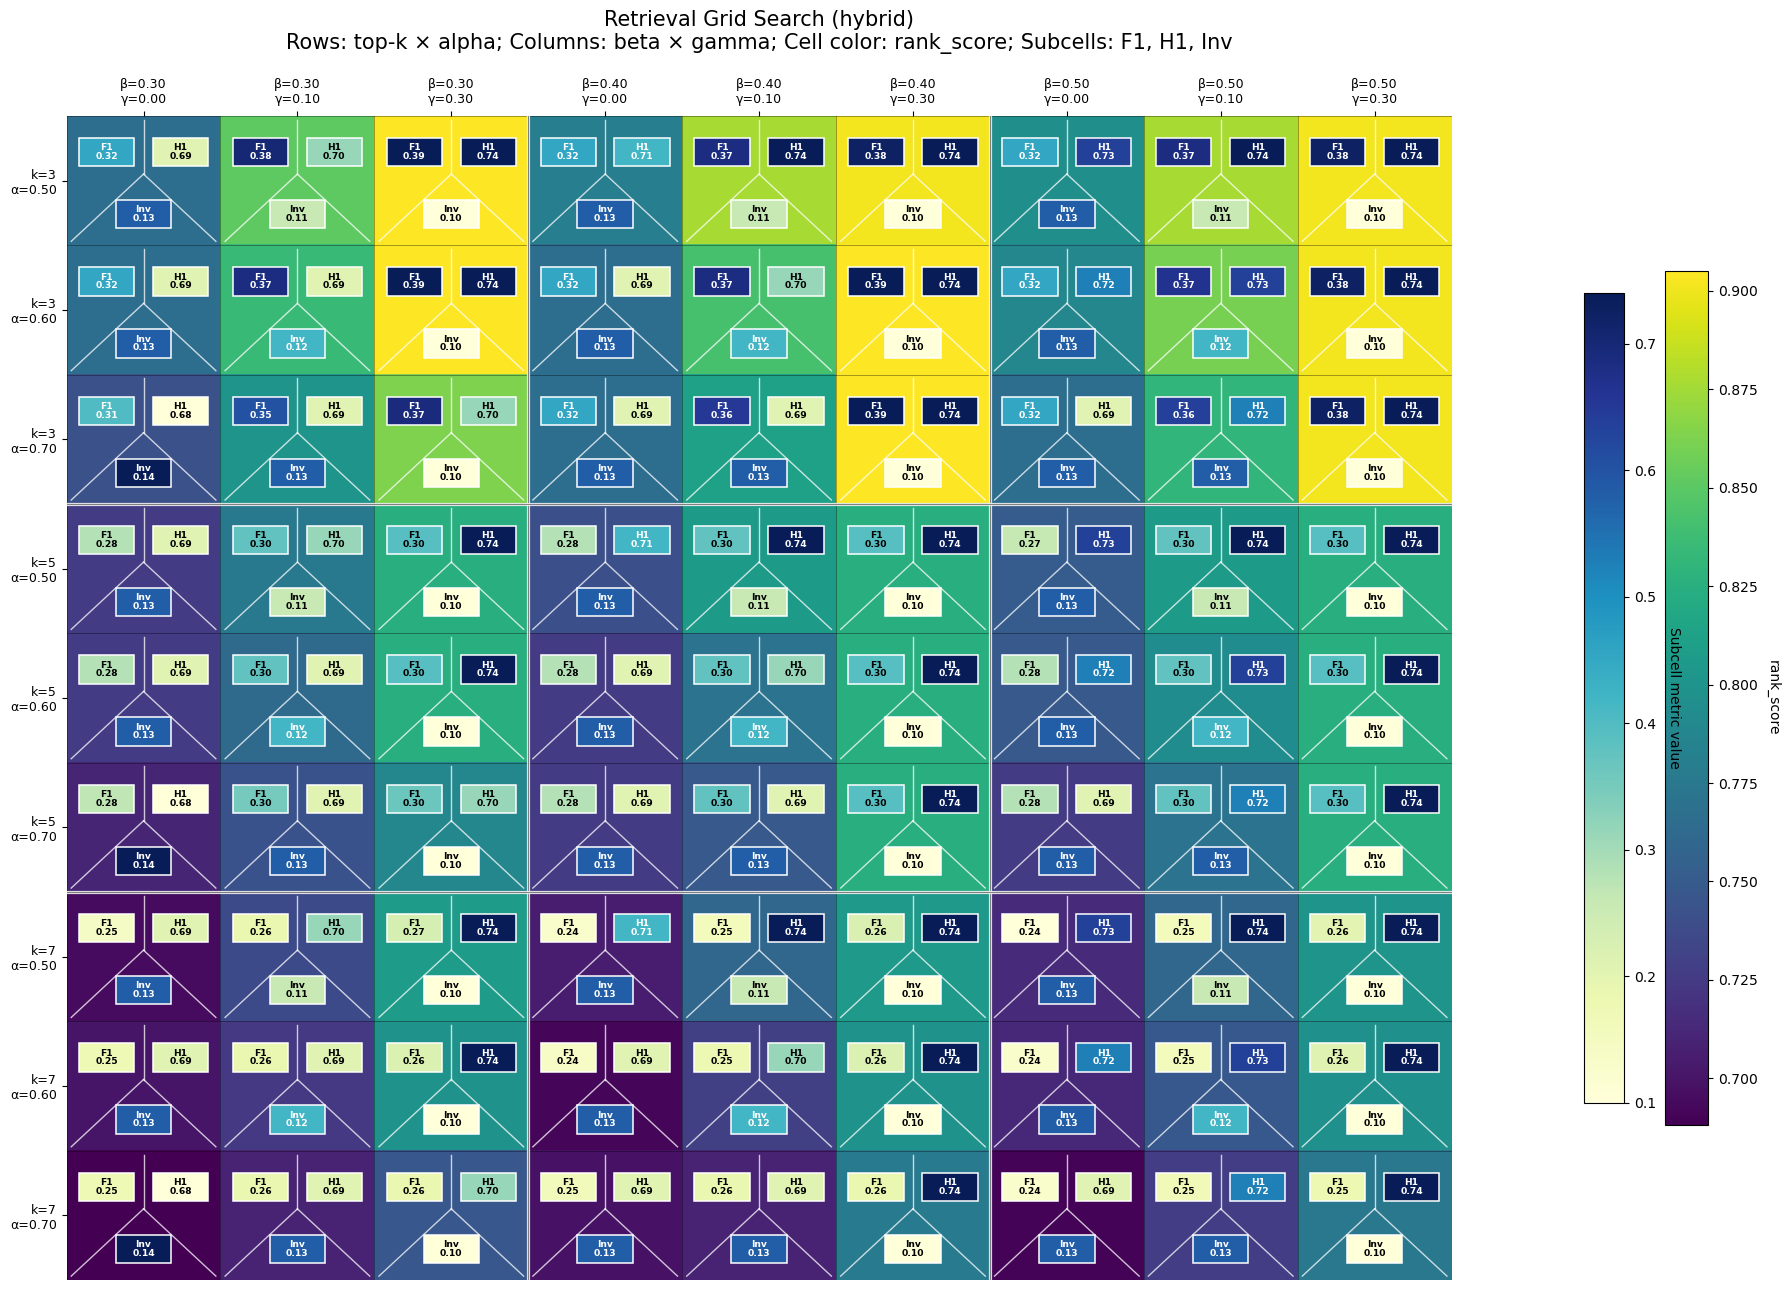

Saved PNG: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\grid_visualizations\retrieval_grid_9x9_subcells_colored_hybrid_rank_score.png
Saved PDF: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\grid_visualizations\retrieval_grid_9x9_subcells_colored_hybrid_rank_score.pdf


In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


# ============================================================
# CONFIG
# ============================================================

INPUT_CSV = Path(
    r"C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\retrieval_grid_summary.csv"
)

OUT_DIR = INPUT_CSV.parent / "grid_visualizations"
OUT_DIR.mkdir(parents=True, exist_ok=True)

POLICY = "hybrid"

DEFAULT_TOP_KS = [3, 5, 7]
DEFAULT_ALPHAS = [0.50, 0.60, 0.70]
DEFAULT_BETAS = [0.30, 0.40, 0.50]
DEFAULT_GAMMAS = [0.00, 0.10, 0.30]

# Цвет основной большой ячейки
COLOR_METRIC = "rank_score"

# Три подячейки внутри каждой клетки.
# Значение каждой подячейки будет окрашиваться по своему metric_col.
SUBCELL_METRICS = [
    ("F1", "evidence_f1"),
    ("H1", "top1_hit"),
    ("Inv", "invalid_top1"),
]

MAIN_CMAP = "viridis"
SUBCELL_CMAP = "YlGnBu"

OUT_PNG = OUT_DIR / f"retrieval_grid_9x9_subcells_colored_{POLICY}_{COLOR_METRIC}.png"
OUT_PDF = OUT_DIR / f"retrieval_grid_9x9_subcells_colored_{POLICY}_{COLOR_METRIC}.pdf"


# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(INPUT_CSV)

if "policy" in df.columns:
    d = df[df["policy"] == POLICY].copy()
else:
    d = df.copy()

if d.empty:
    raise ValueError(f"No rows for POLICY={POLICY}")

for col in ["alpha", "beta", "gamma"]:
    d[col] = d[col].astype(float).round(2)

d["top_k"] = d["top_k"].astype(int)

required = ["top_k", "alpha", "beta", "gamma", COLOR_METRIC] + [c for _, c in SUBCELL_METRICS]
missing = [c for c in required if c not in d.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

print("Loaded:", d.shape)
print(d.head())


# ============================================================
# BUILD GRID
# ============================================================

row_keys = [(k, a) for k in DEFAULT_TOP_KS for a in DEFAULT_ALPHAS]
col_keys = [(b, g) for b in DEFAULT_BETAS for g in DEFAULT_GAMMAS]

Z = np.full((len(row_keys), len(col_keys)), np.nan)
lookup = {}

for _, r in d.iterrows():
    key = (
        int(r["top_k"]),
        round(float(r["alpha"]), 2),
        round(float(r["beta"]), 2),
        round(float(r["gamma"]), 2),
    )
    lookup[key] = r

for i, (top_k, alpha) in enumerate(row_keys):
    for j, (beta, gamma) in enumerate(col_keys):
        key = (top_k, alpha, beta, gamma)
        if key in lookup:
            Z[i, j] = float(lookup[key][COLOR_METRIC])


# ============================================================
# NORMALIZERS
# ============================================================

main_norm = Normalize(
    vmin=np.nanmin(Z),
    vmax=np.nanmax(Z),
)

sub_norms = {}
for label, metric_col in SUBCELL_METRICS:
    vals = d[metric_col].astype(float).values
    sub_norms[metric_col] = Normalize(
        vmin=np.nanmin(vals),
        vmax=np.nanmax(vals),
    )

main_cmap = plt.get_cmap(MAIN_CMAP)
sub_cmap = plt.get_cmap(SUBCELL_CMAP)


def readable_text_color(rgba):
    """
    Choose black/white text based on background luminance.
    """
    r, g, b, _ = rgba
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "black" if luminance > 0.62 else "white"


# ============================================================
# DRAW HELPERS
# ============================================================

def draw_subcell(ax, x, y, w, h, label, value, metric_col, fontsize=6.6):
    """
    Draw one colored subcell inside a major heatmap cell.
    x, y are lower-left coordinates in data units.
    """
    norm = sub_norms[metric_col]
    rgba = sub_cmap(norm(value))
    txt_color = readable_text_color(rgba)

    rect = Rectangle(
        (x, y),
        w,
        h,
        facecolor=rgba,
        edgecolor="white",
        linewidth=1.1,
        zorder=5,
    )
    ax.add_patch(rect)

    txt = f"{label}\n{value:.2f}"

    ax.text(
        x + w / 2,
        y + h / 2,
        txt,
        ha="center",
        va="center",
        fontsize=fontsize,
        color=txt_color,
        fontweight="bold",
        zorder=6,
        linespacing=0.95,
    )


def draw_cell_subdivision(ax, cx, cy):
    """
    Decorative internal division lines inside one heatmap cell.
    """

    left = cx - 0.5
    right = cx + 0.5
    top = cy - 0.5
    bottom = cy + 0.5

    ax.plot(
        [cx, cx],
        [top + 0.03, cy - 0.05],
        color="white",
        linewidth=1.0,
        alpha=0.75,
        zorder=4,
    )

    ax.plot(
        [left + 0.03, cx],
        [bottom - 0.03, cy - 0.05],
        color="white",
        linewidth=1.0,
        alpha=0.75,
        zorder=4,
    )

    ax.plot(
        [right - 0.03, cx],
        [bottom - 0.03, cy - 0.05],
        color="white",
        linewidth=1.0,
        alpha=0.75,
        zorder=4,
    )


def draw_three_subcells(ax, cx, cy, values):
    """
    Three colored boxed subcells:
      top-left
      top-right
      bottom-center
    values: list of tuples (label, value, metric_col)
    """

    w = 0.36
    h = 0.22

    # Top-left
    draw_subcell(
        ax=ax,
        x=cx - 0.42,
        y=cy - 0.33,
        w=w,
        h=h,
        label=values[0][0],
        value=values[0][1],
        metric_col=values[0][2],
    )

    # Top-right
    draw_subcell(
        ax=ax,
        x=cx + 0.06,
        y=cy - 0.33,
        w=w,
        h=h,
        label=values[1][0],
        value=values[1][1],
        metric_col=values[1][2],
    )

    # Bottom-center
    draw_subcell(
        ax=ax,
        x=cx - 0.18,
        y=cy + 0.15,
        w=w,
        h=h,
        label=values[2][0],
        value=values[2][1],
        metric_col=values[2][2],
    )


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(18, 13))

im = ax.imshow(Z, cmap=MAIN_CMAP, norm=main_norm, aspect="auto")

# Major grid lines
for x in np.arange(-0.5, len(col_keys), 1):
    ax.axvline(x, linewidth=0.7, color="black", alpha=0.35, zorder=3)

for y in np.arange(-0.5, len(row_keys), 1):
    ax.axhline(y, linewidth=0.7, color="black", alpha=0.35, zorder=3)

# Strong separators
for x in [2.5, 5.5]:
    ax.axvline(x, linewidth=2.3, color="white", alpha=0.9, zorder=4)
    ax.axvline(x, linewidth=0.9, color="black", alpha=0.45, zorder=4)

for y in [2.5, 5.5]:
    ax.axhline(y, linewidth=2.3, color="white", alpha=0.9, zorder=4)
    ax.axhline(y, linewidth=0.9, color="black", alpha=0.45, zorder=4)


# Internal subdivisions + colored subcells
for i, (top_k, alpha) in enumerate(row_keys):
    for j, (beta, gamma) in enumerate(col_keys):
        key = (top_k, alpha, beta, gamma)

        if key not in lookup:
            continue

        r = lookup[key]

        draw_cell_subdivision(ax, j, i)

        values = []
        for label, col in SUBCELL_METRICS:
            values.append((label, float(r[col]), col))

        draw_three_subcells(ax, j, i, values)


# Axis labels
ax.set_xticks(np.arange(len(col_keys)))
ax.set_yticks(np.arange(len(row_keys)))

ax.set_xticklabels(
    [f"β={b:.2f}\nγ={g:.2f}" for b, g in col_keys],
    fontsize=9,
)

ax.set_yticklabels(
    [f"k={k}\nα={a:.2f}" for k, a in row_keys],
    fontsize=9,
)

ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

ax.set_title(
    f"Retrieval Grid Search ({POLICY})\n"
    f"Rows: top-k × alpha; Columns: beta × gamma; Cell color: {COLOR_METRIC}; "
    f"Subcells: {', '.join([x[0] for x in SUBCELL_METRICS])}",
    fontsize=15,
    pad=48,
)

# Main colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.026, pad=0.025)
cbar.set_label(COLOR_METRIC, rotation=270, labelpad=16)

# Optional subcell colorbar
sm = ScalarMappable(
    cmap=sub_cmap,
    norm=Normalize(
        vmin=min(sub_norms[c].vmin for _, c in SUBCELL_METRICS),
        vmax=max(sub_norms[c].vmax for _, c in SUBCELL_METRICS),
    ),
)
sm.set_array([])

cbar2 = fig.colorbar(sm, ax=ax, fraction=0.026, pad=0.085)
cbar2.set_label("Subcell metric value", rotation=270, labelpad=18)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")

plt.show()

print("Saved PNG:", OUT_PNG)
print("Saved PDF:", OUT_PDF)

Loaded: (81, 15)
                config_name  policy  top_k  alpha  beta  gamma  n_examples  \
0  hybrid_k3_a0.6_b0.3_g0.3  hybrid      3    0.6   0.3    0.3         100   
1  hybrid_k3_a0.5_b0.3_g0.3  hybrid      3    0.5   0.3    0.3         100   
2  hybrid_k3_a0.6_b0.4_g0.3  hybrid      3    0.6   0.4    0.3         100   
3  hybrid_k3_a0.7_b0.4_g0.3  hybrid      3    0.7   0.4    0.3         100   
4  hybrid_k3_a0.6_b0.5_g0.3  hybrid      3    0.6   0.5    0.3         100   

   evidence_precision  evidence_recall  evidence_f1  top1_hit  gold_in_topk  \
0            0.343333            0.455        0.385      0.74          0.78   
1            0.343333            0.455        0.385      0.74          0.78   
2            0.343333            0.455        0.385      0.74          0.78   
3            0.343333            0.455        0.385      0.74          0.78   
4            0.340000            0.450        0.381      0.74          0.78   

   invalid_top1  contradiction_like  ra

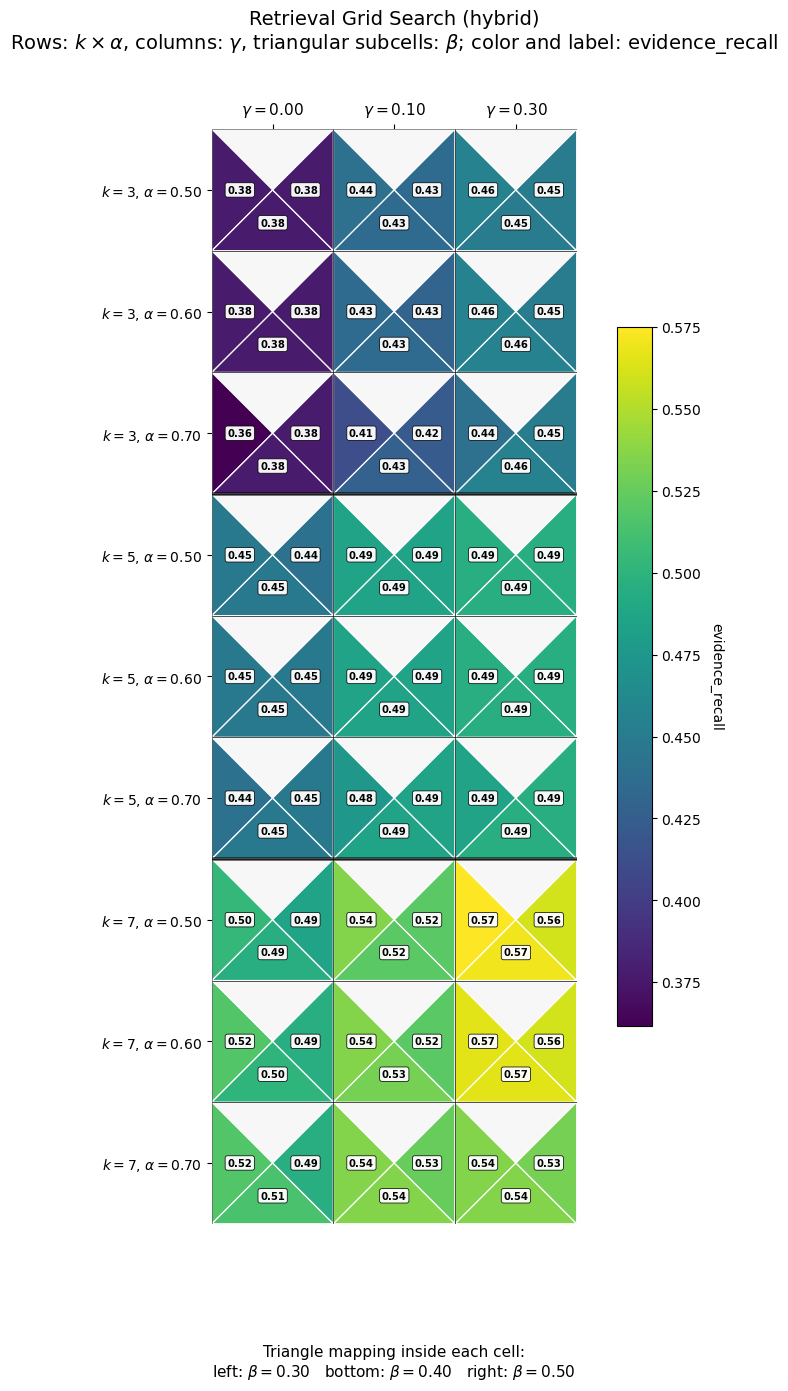

Saved PNG: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\grid_visualizations\grid_triangular_subcells_hybrid_evidence_recall.png
Saved PDF: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\grid_visualizations\grid_triangular_subcells_hybrid_evidence_recall.pdf


In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


# ============================================================
# CONFIG
# ============================================================

INPUT_CSV = Path(
    r"C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\retrieval_grid_summary.csv"
)

OUT_DIR = INPUT_CSV.parent / "grid_visualizations"
OUT_DIR.mkdir(parents=True, exist_ok=True)

POLICY = "hybrid"

TOP_KS = [3, 5, 7]
ALPHAS = [0.50, 0.60, 0.70]
GAMMAS = [0.00, 0.10, 0.30]
BETAS = [0.30, 0.40, 0.50]

# What is shown by color and number inside every triangular subcell
METRIC = "evidence_recall"

CMAP = "viridis"

OUT_PNG = OUT_DIR / f"grid_triangular_subcells_{POLICY}_{METRIC}.png"
OUT_PDF = OUT_DIR / f"grid_triangular_subcells_{POLICY}_{METRIC}.pdf"


# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(INPUT_CSV)

if "policy" in df.columns:
    d = df[df["policy"] == POLICY].copy()
else:
    d = df.copy()

if d.empty:
    raise ValueError(f"No rows for POLICY={POLICY}")

for col in ["alpha", "beta", "gamma"]:
    d[col] = d[col].astype(float).round(2)

d["top_k"] = d["top_k"].astype(int)

required = ["top_k", "alpha", "beta", "gamma", METRIC]
missing = [c for c in required if c not in d.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

print("Loaded:", d.shape)
print(d.head())


# ============================================================
# GRID STRUCTURE
# Rows:    (top_k, alpha) = 9 rows
# Columns: gamma = 3 columns
# Inside each cell:
#   left triangle   -> beta = 0.30
#   bottom triangle -> beta = 0.40
#   right triangle  -> beta = 0.50
# ============================================================

row_keys = [(k, a) for k in TOP_KS for a in ALPHAS]
col_keys = GAMMAS

lookup = {}

for _, r in d.iterrows():
    key = (
        int(r["top_k"]),
        round(float(r["alpha"]), 2),
        round(float(r["beta"]), 2),
        round(float(r["gamma"]), 2),
    )
    lookup[key] = r


# Global normalization across all subcells, not per cell
vals = []

for k, a in row_keys:
    for g in col_keys:
        for b in BETAS:
            key = (k, a, b, g)
            if key in lookup:
                vals.append(float(lookup[key][METRIC]))

if not vals:
    raise ValueError("No matching grid values found.")

norm = Normalize(vmin=min(vals), vmax=max(vals))
cmap = plt.get_cmap(CMAP)


# ============================================================
# DRAW HELPERS
# ============================================================

def metric_value(k, a, b, g):
    key = (k, a, b, g)
    if key not in lookup:
        return None
    return float(lookup[key][METRIC])


def draw_metric_label(ax, x, y, value, fontsize=7.2):
    """
    White bbox with only the recall value inside.
    """
    ax.text(
        x,
        y,
        f"{value:.2f}",
        ha="center",
        va="center",
        fontsize=fontsize,
        color="black",
        fontweight="bold",
        zorder=8,
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor="white",
            edgecolor="black",
            linewidth=0.55,
            alpha=0.95,
        ),
    )


def draw_triangular_cell(ax, cx, cy, top_k, alpha, gamma):
    """
    Draw one major cell split into 3 colored triangular subcells:
      left   beta=0.30
      bottom beta=0.40
      right  beta=0.50

    The upper triangle is left as light neutral background to avoid overlap.
    """

    left = cx - 0.5
    right = cx + 0.5
    top = cy - 0.5
    bottom = cy + 0.5
    center = (cx, cy)

    # Light top area, just to make the triangular structure explicit
    top_poly = Polygon(
        [(left, top), (right, top), center],
        closed=True,
        facecolor="#f7f7f7",
        edgecolor="white",
        linewidth=0.75,
        zorder=2,
    )
    ax.add_patch(top_poly)

    # beta -> polygon mapping
    pieces = [
        # beta, polygon points, label position
        (BETAS[0], [(left, top), (left, bottom), center], (cx - 0.27, cy)),
        (BETAS[1], [(left, bottom), (right, bottom), center], (cx, cy + 0.27)),
        (BETAS[2], [(right, top), (right, bottom), center], (cx + 0.27, cy)),
    ]

    for beta, points, label_xy in pieces:
        val = metric_value(top_k, alpha, beta, gamma)

        if val is None:
            face = "#eeeeee"
        else:
            face = cmap(norm(val))

        poly = Polygon(
            points,
            closed=True,
            facecolor=face,
            edgecolor="white",
            linewidth=0.9,
            zorder=4,
        )
        ax.add_patch(poly)

        if val is not None:
            draw_metric_label(ax, label_xy[0], label_xy[1], val)

    # Outer border
    border = Polygon(
        [(left, top), (right, top), (right, bottom), (left, bottom)],
        closed=True,
        facecolor="none",
        edgecolor="black",
        linewidth=0.55,
        alpha=0.55,
        zorder=9,
    )
    ax.add_patch(border)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(11, 14))

# Empty background
ax.set_xlim(-0.5, len(col_keys) - 0.5)
ax.set_ylim(len(row_keys) - 0.5, -0.5)
ax.set_aspect("equal")

# Draw all major cells
for i, (top_k, alpha) in enumerate(row_keys):
    for j, gamma in enumerate(col_keys):
        draw_triangular_cell(
            ax=ax,
            cx=j,
            cy=i,
            top_k=top_k,
            alpha=alpha,
            gamma=gamma,
        )

# Strong separators between top_k blocks
for y in [2.5, 5.5]:
    ax.axhline(y, linewidth=2.6, color="black", alpha=0.65, zorder=10)

# Axis ticks
ax.set_xticks(np.arange(len(col_keys)))
ax.set_yticks(np.arange(len(row_keys)))

ax.set_xticklabels(
    [f"$\\gamma={g:.2f}$" for g in col_keys],
    fontsize=11,
)

ax.set_yticklabels(
    [f"$k={k}$, $\\alpha={a:.2f}$" for k, a in row_keys],
    fontsize=10,
)

ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

# Beta legend as text
legend_text = (
    "Triangle mapping inside each cell:\n"
    f"left: $\\beta={BETAS[0]:.2f}$   "
    f"bottom: $\\beta={BETAS[1]:.2f}$   "
    f"right: $\\beta={BETAS[2]:.2f}$"
)

ax.text(
    0.5,
    -0.11,
    legend_text,
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=11,
)

ax.set_title(
    f"Retrieval Grid Search ({POLICY})\n"
    f"Rows: $k \\times \\alpha$, columns: $\\gamma$, triangular subcells: $\\beta$; color and label: {METRIC}",
    fontsize=14,
    pad=58,
)

# Colorbar shared across all triangular subcells
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label(METRIC, rotation=270, labelpad=16)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")

plt.show()

print("Saved PNG:", OUT_PNG)
print("Saved PDF:", OUT_PDF)

Loaded all rows: (243, 15)
Policies: ['hybrid', 'original', 'querytime']
Expected rows: 243
Metric range: evidence_recall 0.3616666666666667 0.62


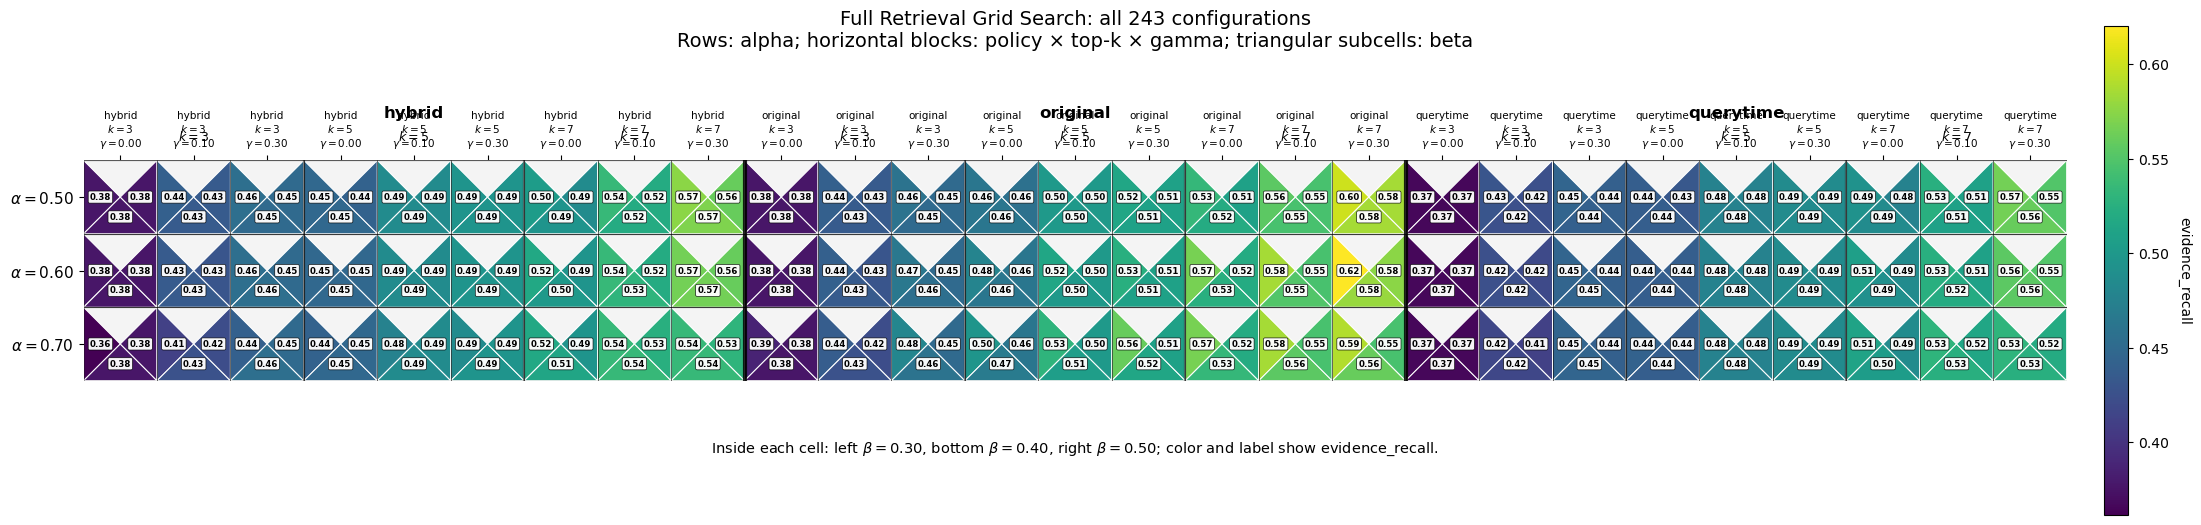

Saved PNG: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\grid_visualizations\grid_all_243_horizontal_blocks_evidence_recall.png
Saved PDF: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\grid_visualizations\grid_all_243_horizontal_blocks_evidence_recall.pdf


In [10]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


# ============================================================
# CONFIG
# ============================================================

INPUT_CSV = Path(
    r"C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\retrieval_grid_summary.csv"
)

OUT_DIR = INPUT_CSV.parent / "grid_visualizations"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_KS = [3, 5, 7]
ALPHAS = [0.50, 0.60, 0.70]
BETAS = [0.30, 0.40, 0.50]
GAMMAS = [0.00, 0.10, 0.30]

# Metric shown by color and number inside every triangular subcell
METRIC = "evidence_recall"

CMAP = "viridis"

OUT_PNG = OUT_DIR / f"grid_all_243_horizontal_blocks_{METRIC}.png"
OUT_PDF = OUT_DIR / f"grid_all_243_horizontal_blocks_{METRIC}.pdf"


# ============================================================
# LOAD ALL 243 ROWS
# ============================================================

df = pd.read_csv(INPUT_CSV).copy()

for col in ["alpha", "beta", "gamma"]:
    df[col] = df[col].astype(float).round(2)

df["top_k"] = df["top_k"].astype(int)

required = ["policy", "top_k", "alpha", "beta", "gamma", METRIC]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

policies = sorted(df["policy"].dropna().unique().tolist())

print("Loaded all rows:", df.shape)
print("Policies:", policies)
print("Expected rows:", len(policies) * len(TOP_KS) * len(ALPHAS) * len(BETAS) * len(GAMMAS))


# ============================================================
# GRID STRUCTURE
# Rows:    alpha = 3 rows
# Columns: policy × top_k × gamma = 27 columns
# Inside each major cell:
#   left triangle   -> beta = 0.30
#   bottom triangle -> beta = 0.40
#   right triangle  -> beta = 0.50
# ============================================================

row_keys = ALPHAS

col_keys = [
    (policy, k, g)
    for policy in policies
    for k in TOP_KS
    for g in GAMMAS
]

lookup = {}

for _, r in df.iterrows():
    key = (
        str(r["policy"]),
        int(r["top_k"]),
        round(float(r["alpha"]), 2),
        round(float(r["beta"]), 2),
        round(float(r["gamma"]), 2),
    )
    lookup[key] = r


# Global normalization across all 243 subcells
vals = []

for alpha in row_keys:
    for policy, k, gamma in col_keys:
        for beta in BETAS:
            key = (policy, k, alpha, beta, gamma)
            if key in lookup:
                vals.append(float(lookup[key][METRIC]))

if not vals:
    raise ValueError("No matching grid values found.")

norm = Normalize(vmin=min(vals), vmax=max(vals))
cmap = plt.get_cmap(CMAP)

print("Metric range:", METRIC, min(vals), max(vals))


# ============================================================
# DRAW HELPERS
# ============================================================

def metric_value(policy, k, alpha, beta, gamma):
    key = (policy, k, alpha, beta, gamma)
    if key not in lookup:
        return None
    return float(lookup[key][METRIC])


def draw_metric_label(ax, x, y, value, fontsize=6.2):
    """
    White bbox with only the metric value inside.
    """
    ax.text(
        x,
        y,
        f"{value:.2f}",
        ha="center",
        va="center",
        fontsize=fontsize,
        color="black",
        fontweight="bold",
        zorder=8,
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor="white",
            edgecolor="black",
            linewidth=0.45,
            alpha=0.96,
        ),
    )


def draw_triangular_cell(ax, cx, cy, policy, top_k, alpha, gamma):
    """
    Draw one major cell split into 3 colored triangular subcells:
      left   beta=0.30
      bottom beta=0.40
      right  beta=0.50

    Top triangle is neutral.
    """

    left = cx - 0.5
    right = cx + 0.5
    top = cy - 0.5
    bottom = cy + 0.5
    center = (cx, cy)

    # Neutral upper triangle
    top_poly = Polygon(
        [(left, top), (right, top), center],
        closed=True,
        facecolor="#f4f4f4",
        edgecolor="white",
        linewidth=0.6,
        zorder=2,
    )
    ax.add_patch(top_poly)

    pieces = [
        # beta, polygon points, label position
        (BETAS[0], [(left, top), (left, bottom), center], (cx - 0.27, cy)),
        (BETAS[1], [(left, bottom), (right, bottom), center], (cx, cy + 0.27)),
        (BETAS[2], [(right, top), (right, bottom), center], (cx + 0.27, cy)),
    ]

    for beta, points, label_xy in pieces:
        val = metric_value(policy, top_k, alpha, beta, gamma)

        if val is None:
            face = "#e6e6e6"
        else:
            face = cmap(norm(val))

        poly = Polygon(
            points,
            closed=True,
            facecolor=face,
            edgecolor="white",
            linewidth=0.75,
            zorder=4,
        )
        ax.add_patch(poly)

        if val is not None:
            draw_metric_label(ax, label_xy[0], label_xy[1], val)

    # Outer border
    border = Polygon(
        [(left, top), (right, top), (right, bottom), (left, bottom)],
        closed=True,
        facecolor="none",
        edgecolor="black",
        linewidth=0.45,
        alpha=0.55,
        zorder=9,
    )
    ax.add_patch(border)


# ============================================================
# PLOT HORIZONTAL BLOCKS
# ============================================================

fig_w = max(18, 0.82 * len(col_keys))
fig_h = 5.5

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

ax.set_xlim(-0.5, len(col_keys) - 0.5)
ax.set_ylim(len(row_keys) - 0.5, -0.5)
ax.set_aspect("equal")


# Draw all cells
for i, alpha in enumerate(row_keys):
    for j, (policy, top_k, gamma) in enumerate(col_keys):
        draw_triangular_cell(
            ax=ax,
            cx=j,
            cy=i,
            policy=policy,
            top_k=top_k,
            alpha=alpha,
            gamma=gamma,
        )


# ============================================================
# SEPARATORS
# ============================================================

cols_per_policy = len(TOP_KS) * len(GAMMAS)  # 9
cols_per_k = len(GAMMAS)                     # 3

# Policy separators: big vertical blocks
for x in [cols_per_policy - 0.5, 2 * cols_per_policy - 0.5]:
    ax.axvline(x, linewidth=3.0, color="black", alpha=0.85, zorder=10)

# Top-k separators inside each policy
for p_idx in range(len(policies)):
    base = p_idx * cols_per_policy

    for x in [
        base + cols_per_k - 0.5,
        base + 2 * cols_per_k - 0.5,
    ]:
        ax.axvline(x, linewidth=1.6, color="black", alpha=0.45, zorder=10)

# Row separators
for y in np.arange(-0.5, len(row_keys), 1):
    ax.axhline(y, linewidth=0.9, color="black", alpha=0.45, zorder=10)


# ============================================================
# AXIS LABELS
# ============================================================

ax.set_yticks(np.arange(len(row_keys)))
ax.set_yticklabels(
    [f"$\\alpha={a:.2f}$" for a in row_keys],
    fontsize=11,
)

ax.set_xticks(np.arange(len(col_keys)))
ax.set_xticklabels(
    [
        f"{policy}\n$k={k}$\n$\\gamma={g:.2f}$"
        for policy, k, g in col_keys
    ],
    fontsize=7.5,
    rotation=0,
)

ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)


# Group labels above policy blocks
for p_idx, policy in enumerate(policies):
    start = p_idx * cols_per_policy
    end = start + cols_per_policy - 1
    center = (start + end) / 2

    ax.text(
        center,
        -1.15,
        f"{policy}",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        transform=ax.transData,
        clip_on=False,
    )


# Group labels above top-k blocks
for p_idx, policy in enumerate(policies):
    base = p_idx * cols_per_policy

    for k_idx, k in enumerate(TOP_KS):
        start = base + k_idx * cols_per_k
        end = start + cols_per_k - 1
        center = (start + end) / 2

        ax.text(
            center,
            -0.82,
            f"$k={k}$",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            transform=ax.transData,
            clip_on=False,
        )


# Legend for beta triangular mapping
legend_text = (
    "Inside each cell: "
    f"left $\\beta={BETAS[0]:.2f}$, "
    f"bottom $\\beta={BETAS[1]:.2f}$, "
    f"right $\\beta={BETAS[2]:.2f}$; "
    f"color and label show {METRIC}."
)

ax.text(
    0.5,
    -0.27,
    legend_text,
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=10.5,
)


ax.set_title(
    f"Full Retrieval Grid Search: all {len(df)} configurations\n"
    f"Rows: alpha; horizontal blocks: policy × top-k × gamma; triangular subcells: beta",
    fontsize=14,
    pad=82,
)


# Shared colorbar across all 243 triangular subcells
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, fraction=0.018, pad=0.018)
cbar.set_label(METRIC, rotation=270, labelpad=16)


for spine in ax.spines.values():
    spine.set_visible(False)


plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")

plt.show()

print("Saved PNG:", OUT_PNG)
print("Saved PDF:", OUT_PDF)

Loaded all rows: (243, 15)
Policies: ['hybrid', 'original', 'querytime']
Expected configurations: 243
Metric range: evidence_recall 0.3616666666666667 0.62


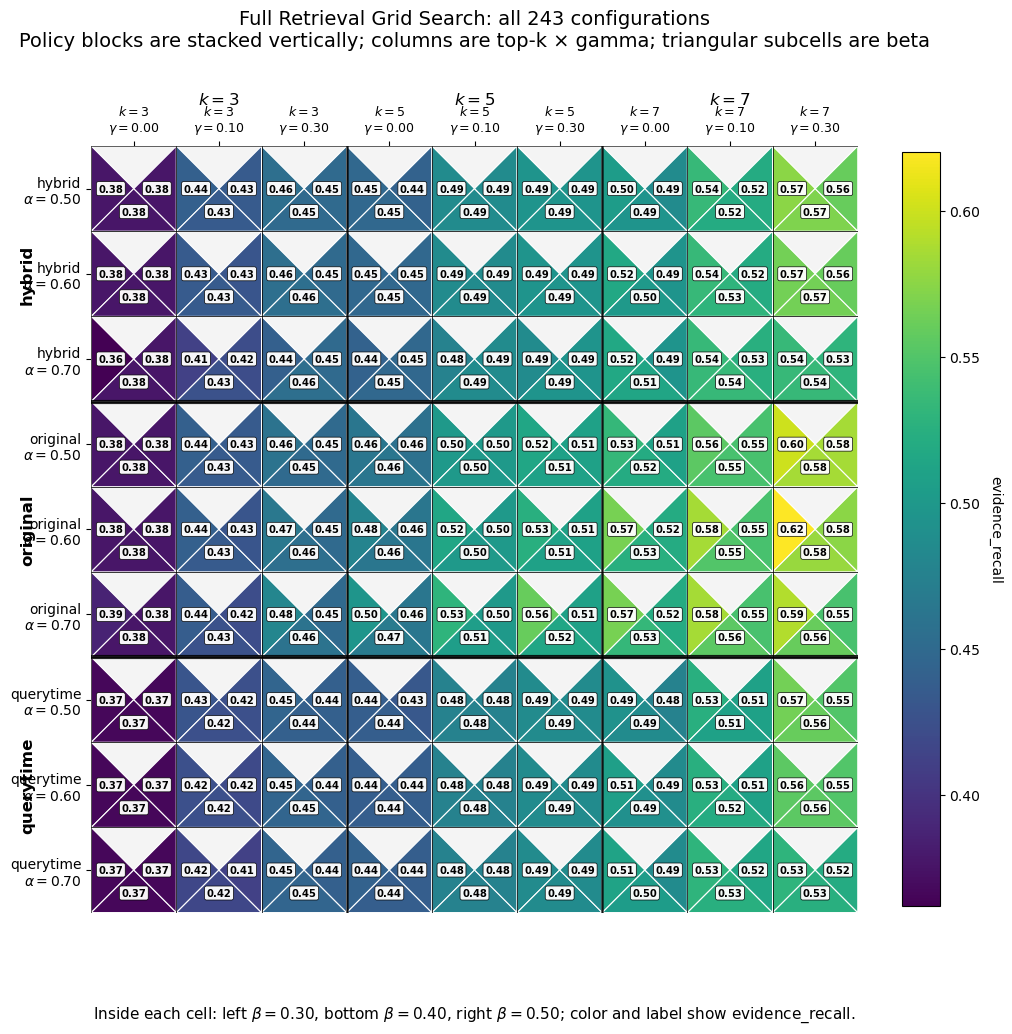

Saved PNG: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\grid_visualizations\grid_all_243_policy_blocks_vertical_evidence_recall.png
Saved PDF: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\grid_visualizations\grid_all_243_policy_blocks_vertical_evidence_recall.pdf


In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


# ============================================================
# CONFIG
# ============================================================

INPUT_CSV = Path(
    r"C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\retrieval_grid_summary.csv"
)

OUT_DIR = INPUT_CSV.parent / "grid_visualizations"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_KS = [3, 5, 7]
ALPHAS = [0.50, 0.60, 0.70]
BETAS = [0.30, 0.40, 0.50]
GAMMAS = [0.00, 0.10, 0.30]

# Metric shown by color and number inside each triangular subcell
METRIC = "evidence_recall"

CMAP = "viridis"

OUT_PNG = OUT_DIR / f"grid_all_243_policy_blocks_vertical_{METRIC}.png"
OUT_PDF = OUT_DIR / f"grid_all_243_policy_blocks_vertical_{METRIC}.pdf"


# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(INPUT_CSV).copy()

for col in ["alpha", "beta", "gamma"]:
    df[col] = df[col].astype(float).round(2)

df["top_k"] = df["top_k"].astype(int)

required = ["policy", "top_k", "alpha", "beta", "gamma", METRIC]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Preserve readable order if these policies exist
preferred_policy_order = ["hybrid", "original", "querytime"]
available = df["policy"].dropna().unique().tolist()

policies = [p for p in preferred_policy_order if p in available]
policies += [p for p in sorted(available) if p not in policies]

print("Loaded all rows:", df.shape)
print("Policies:", policies)
print("Expected configurations:", len(policies) * len(TOP_KS) * len(ALPHAS) * len(BETAS) * len(GAMMAS))


# ============================================================
# GRID STRUCTURE
# Rows: policy × alpha = 3 × 3 = 9 rows
# Columns: top_k × gamma = 3 × 3 = 9 columns
# Inside each major cell:
#   left triangle   -> beta=0.30
#   bottom triangle -> beta=0.40
#   right triangle  -> beta=0.50
# ============================================================

row_keys = [
    (policy, alpha)
    for policy in policies
    for alpha in ALPHAS
]

col_keys = [
    (top_k, gamma)
    for top_k in TOP_KS
    for gamma in GAMMAS
]

lookup = {}

for _, r in df.iterrows():
    key = (
        str(r["policy"]),
        int(r["top_k"]),
        round(float(r["alpha"]), 2),
        round(float(r["beta"]), 2),
        round(float(r["gamma"]), 2),
    )
    lookup[key] = r


# Global normalization across all 243 triangular subcells
vals = []

for policy, alpha in row_keys:
    for top_k, gamma in col_keys:
        for beta in BETAS:
            key = (policy, top_k, alpha, beta, gamma)
            if key in lookup:
                vals.append(float(lookup[key][METRIC]))

if not vals:
    raise ValueError("No matching grid values found.")

norm = Normalize(vmin=min(vals), vmax=max(vals))
cmap = plt.get_cmap(CMAP)

print("Metric range:", METRIC, min(vals), max(vals))


# ============================================================
# DRAW HELPERS
# ============================================================

def metric_value(policy, top_k, alpha, beta, gamma):
    key = (policy, top_k, alpha, beta, gamma)
    if key not in lookup:
        return None
    return float(lookup[key][METRIC])


def draw_metric_label(ax, x, y, value, fontsize=7.2):
    """
    White bbox with only the metric value inside.
    """
    ax.text(
        x,
        y,
        f"{value:.2f}",
        ha="center",
        va="center",
        fontsize=fontsize,
        color="black",
        fontweight="bold",
        zorder=8,
        bbox=dict(
            boxstyle="round,pad=0.20",
            facecolor="white",
            edgecolor="black",
            linewidth=0.50,
            alpha=0.96,
        ),
    )


def draw_triangular_cell(ax, cx, cy, policy, top_k, alpha, gamma):
    """
    One major cell split into three colored triangular subcells:
      left   beta=0.30
      bottom beta=0.40
      right  beta=0.50

    The top triangle is neutral.
    """

    left = cx - 0.5
    right = cx + 0.5
    top = cy - 0.5
    bottom = cy + 0.5
    center = (cx, cy)

    # Neutral top triangle
    top_poly = Polygon(
        [(left, top), (right, top), center],
        closed=True,
        facecolor="#f4f4f4",
        edgecolor="white",
        linewidth=0.70,
        zorder=2,
    )
    ax.add_patch(top_poly)

    pieces = [
        # beta, polygon points, label position
        (BETAS[0], [(left, top), (left, bottom), center], (cx - 0.27, cy)),
        (BETAS[1], [(left, bottom), (right, bottom), center], (cx, cy + 0.27)),
        (BETAS[2], [(right, top), (right, bottom), center], (cx + 0.27, cy)),
    ]

    for beta, points, label_xy in pieces:
        val = metric_value(policy, top_k, alpha, beta, gamma)

        if val is None:
            face = "#e6e6e6"
        else:
            face = cmap(norm(val))

        poly = Polygon(
            points,
            closed=True,
            facecolor=face,
            edgecolor="white",
            linewidth=0.80,
            zorder=4,
        )
        ax.add_patch(poly)

        if val is not None:
            draw_metric_label(ax, label_xy[0], label_xy[1], val)

    # Outer border
    border = Polygon(
        [(left, top), (right, top), (right, bottom), (left, bottom)],
        closed=True,
        facecolor="none",
        edgecolor="black",
        linewidth=0.50,
        alpha=0.60,
        zorder=9,
    )
    ax.add_patch(border)


# ============================================================
# PLOT: POLICY BLOCKS STACKED VERTICALLY
# ============================================================

fig_w = 13.5
fig_h = 10.5

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

ax.set_xlim(-0.5, len(col_keys) - 0.5)
ax.set_ylim(len(row_keys) - 0.5, -0.5)
ax.set_aspect("equal")


# Draw cells
for i, (policy, alpha) in enumerate(row_keys):
    for j, (top_k, gamma) in enumerate(col_keys):
        draw_triangular_cell(
            ax=ax,
            cx=j,
            cy=i,
            policy=policy,
            top_k=top_k,
            alpha=alpha,
            gamma=gamma,
        )


# ============================================================
# SEPARATORS
# ============================================================

rows_per_policy = len(ALPHAS)  # 3
cols_per_k = len(GAMMAS)       # 3

# Horizontal separators between policy blocks
for y in [rows_per_policy - 0.5, 2 * rows_per_policy - 0.5]:
    ax.axhline(y, linewidth=3.0, color="black", alpha=0.85, zorder=10)

# Thin row separators
for y in np.arange(-0.5, len(row_keys), 1):
    ax.axhline(y, linewidth=0.65, color="black", alpha=0.35, zorder=10)

# Vertical separators between top-k blocks
for x in [cols_per_k - 0.5, 2 * cols_per_k - 0.5]:
    ax.axvline(x, linewidth=2.0, color="black", alpha=0.65, zorder=10)

# Thin column separators
for x in np.arange(-0.5, len(col_keys), 1):
    ax.axvline(x, linewidth=0.65, color="black", alpha=0.35, zorder=10)


# ============================================================
# AXIS LABELS
# ============================================================

ax.set_xticks(np.arange(len(col_keys)))
ax.set_xticklabels(
    [f"$k={k}$\n$\\gamma={g:.2f}$" for k, g in col_keys],
    fontsize=9,
)

ax.set_yticks(np.arange(len(row_keys)))
ax.set_yticklabels(
    [f"{policy}\n$\\alpha={alpha:.2f}$" for policy, alpha in row_keys],
    fontsize=10,
)

ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)


# Top group labels for k blocks
for k_idx, top_k in enumerate(TOP_KS):
    start = k_idx * cols_per_k
    end = start + cols_per_k - 1
    center = (start + end) / 2

    ax.text(
        center,
        -1.05,
        f"$k={top_k}$",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        transform=ax.transData,
        clip_on=False,
    )


# Left group labels for policy blocks
for p_idx, policy in enumerate(policies):
    start = p_idx * rows_per_policy
    end = start + rows_per_policy - 1
    center = (start + end) / 2

    ax.text(
        -1.25,
        center,
        policy,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        rotation=90,
        transform=ax.transData,
        clip_on=False,
    )


# Beta legend
legend_text = (
    "Inside each cell: "
    f"left $\\beta={BETAS[0]:.2f}$, "
    f"bottom $\\beta={BETAS[1]:.2f}$, "
    f"right $\\beta={BETAS[2]:.2f}$; "
    f"color and label show {METRIC}."
)

ax.text(
    0.5,
    -0.12,
    legend_text,
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=11,
)


ax.set_title(
    f"Full Retrieval Grid Search: all {len(df)} configurations\n"
    f"Policy blocks are stacked vertically; columns are top-k × gamma; triangular subcells are beta",
    fontsize=14,
    pad=72,
)


# Shared colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, fraction=0.030, pad=0.035)
cbar.set_label(METRIC, rotation=270, labelpad=16)


for spine in ax.spines.values():
    spine.set_visible(False)


plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")

plt.show()

print("Saved PNG:", OUT_PNG)
print("Saved PDF:", OUT_PDF)

Loaded all rows: (243, 15)
Policies: ['hybrid', 'original', 'querytime']
Expected configurations: 243
Metric range: evidence_recall 0.3616666666666667 0.62


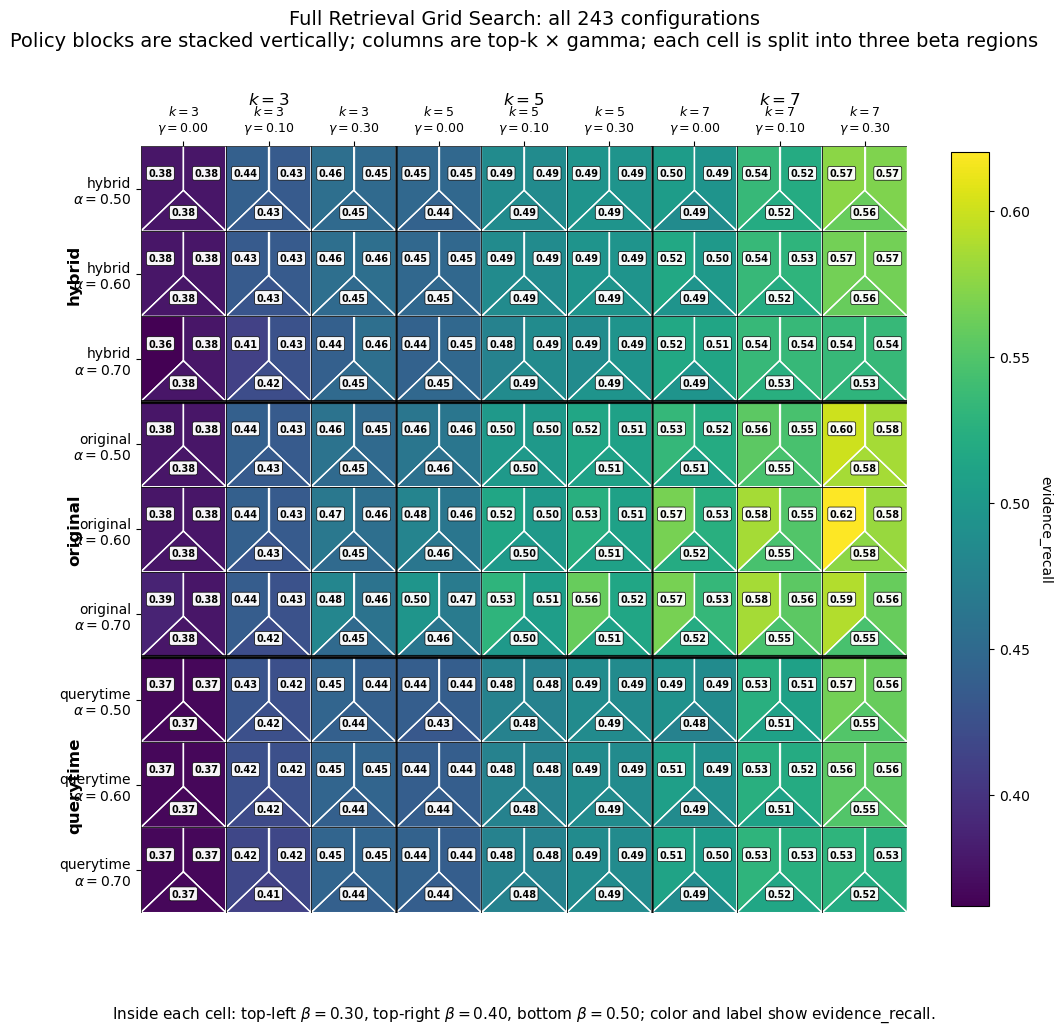

Saved PNG: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\grid_visualizations\grid_all_243_policy_blocks_vertical_three_parts_evidence_recall.png
Saved PDF: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\grid_visualizations\grid_all_243_policy_blocks_vertical_three_parts_evidence_recall.pdf


In [12]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


# ============================================================
# CONFIG
# ============================================================

INPUT_CSV = Path(
    r"C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\retrieval_grid_summary.csv"
)

OUT_DIR = INPUT_CSV.parent / "grid_visualizations"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_KS = [3, 5, 7]
ALPHAS = [0.50, 0.60, 0.70]
BETAS = [0.30, 0.40, 0.50]
GAMMAS = [0.00, 0.10, 0.30]

# Metric shown by color and value inside each subcell
METRIC = "evidence_recall"

CMAP = "viridis"

OUT_PNG = OUT_DIR / f"grid_all_243_policy_blocks_vertical_three_parts_{METRIC}.png"
OUT_PDF = OUT_DIR / f"grid_all_243_policy_blocks_vertical_three_parts_{METRIC}.pdf"


# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(INPUT_CSV).copy()

for col in ["alpha", "beta", "gamma"]:
    df[col] = df[col].astype(float).round(2)

df["top_k"] = df["top_k"].astype(int)

required = ["policy", "top_k", "alpha", "beta", "gamma", METRIC]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

preferred_policy_order = ["hybrid", "original", "querytime"]
available = df["policy"].dropna().unique().tolist()

policies = [p for p in preferred_policy_order if p in available]
policies += [p for p in sorted(available) if p not in policies]

print("Loaded all rows:", df.shape)
print("Policies:", policies)
print("Expected configurations:", len(policies) * len(TOP_KS) * len(ALPHAS) * len(BETAS) * len(GAMMAS))


# ============================================================
# GRID STRUCTURE
# Rows: policy × alpha = 3 × 3 = 9 rows
# Columns: top_k × gamma = 3 × 3 = 9 columns
#
# Each major cell is divided into 3 regions:
#   top-left  -> beta=0.30
#   top-right -> beta=0.40
#   bottom    -> beta=0.50
# ============================================================

row_keys = [
    (policy, alpha)
    for policy in policies
    for alpha in ALPHAS
]

col_keys = [
    (top_k, gamma)
    for top_k in TOP_KS
    for gamma in GAMMAS
]

lookup = {}

for _, r in df.iterrows():
    key = (
        str(r["policy"]),
        int(r["top_k"]),
        round(float(r["alpha"]), 2),
        round(float(r["beta"]), 2),
        round(float(r["gamma"]), 2),
    )
    lookup[key] = r


# Global normalization across all 243 parts
vals = []

for policy, alpha in row_keys:
    for top_k, gamma in col_keys:
        for beta in BETAS:
            key = (policy, top_k, alpha, beta, gamma)
            if key in lookup:
                vals.append(float(lookup[key][METRIC]))

if not vals:
    raise ValueError("No matching grid values found.")

norm = Normalize(vmin=min(vals), vmax=max(vals))
cmap = plt.get_cmap(CMAP)

print("Metric range:", METRIC, min(vals), max(vals))


# ============================================================
# DRAW HELPERS
# ============================================================

def metric_value(policy, top_k, alpha, beta, gamma):
    key = (policy, top_k, alpha, beta, gamma)
    if key not in lookup:
        return None
    return float(lookup[key][METRIC])


def draw_metric_label(ax, x, y, value, fontsize=7.0):
    """
    White bbox with only the metric value inside.
    """
    ax.text(
        x,
        y,
        f"{value:.2f}",
        ha="center",
        va="center",
        fontsize=fontsize,
        color="black",
        fontweight="bold",
        zorder=10,
        bbox=dict(
            boxstyle="round,pad=0.20",
            facecolor="white",
            edgecolor="black",
            linewidth=0.50,
            alpha=0.96,
        ),
    )


def draw_three_part_cell(ax, cx, cy, policy, top_k, alpha, gamma):
    """
    Cell split into three regions:
      top-left  beta=0.30
      top-right beta=0.40
      bottom    beta=0.50

    Geometry follows the earlier sketch:
      - vertical split at the top;
      - two diagonals to a central lower point;
      - bottom wedge.
    """

    left = cx - 0.5
    right = cx + 0.5
    top = cy - 0.5
    bottom = cy + 0.5

    # Pivot slightly above the vertical center so the bottom wedge is visible
    pivot = (cx, cy + 0.02)

    # Regions:
    # top-left: left/top corner -> top center -> pivot -> bottom-left
    # top-right: top center -> right/top -> bottom-right -> pivot
    # bottom: bottom-left -> bottom-right -> pivot
    regions = [
        {
            "beta": BETAS[0],
            "points": [(left, top), (cx, top), pivot, (left, bottom)],
            "label_xy": (cx - 0.27, cy - 0.18),
        },
        {
            "beta": BETAS[1],
            "points": [(cx, top), (right, top), (right, bottom), pivot],
            "label_xy": (cx + 0.27, cy - 0.18),
        },
        {
            "beta": BETAS[2],
            "points": [(left, bottom), (right, bottom), pivot],
            "label_xy": (cx, cy + 0.28),
        },
    ]

    for region in regions:
        beta = region["beta"]
        val = metric_value(policy, top_k, alpha, beta, gamma)

        if val is None:
            face = "#e6e6e6"
        else:
            face = cmap(norm(val))

        poly = Polygon(
            region["points"],
            closed=True,
            facecolor=face,
            edgecolor="white",
            linewidth=0.90,
            zorder=4,
        )
        ax.add_patch(poly)

        if val is not None:
            draw_metric_label(
                ax,
                region["label_xy"][0],
                region["label_xy"][1],
                val,
            )

    # Outer border
    border = Polygon(
        [(left, top), (right, top), (right, bottom), (left, bottom)],
        closed=True,
        facecolor="none",
        edgecolor="black",
        linewidth=0.55,
        alpha=0.65,
        zorder=11,
    )
    ax.add_patch(border)

    # Optional internal boundaries for clearer three-part division
    ax.plot(
        [cx, cx],
        [top, pivot[1]],
        color="white",
        linewidth=0.95,
        alpha=0.95,
        zorder=9,
    )
    ax.plot(
        [left, pivot[0]],
        [bottom, pivot[1]],
        color="white",
        linewidth=0.95,
        alpha=0.95,
        zorder=9,
    )
    ax.plot(
        [right, pivot[0]],
        [bottom, pivot[1]],
        color="white",
        linewidth=0.95,
        alpha=0.95,
        zorder=9,
    )


# ============================================================
# PLOT: POLICY BLOCKS STACKED VERTICALLY
# ============================================================

fig_w = 13.5
fig_h = 10.5

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

ax.set_xlim(-0.5, len(col_keys) - 0.5)
ax.set_ylim(len(row_keys) - 0.5, -0.5)
ax.set_aspect("equal")


# Draw all cells
for i, (policy, alpha) in enumerate(row_keys):
    for j, (top_k, gamma) in enumerate(col_keys):
        draw_three_part_cell(
            ax=ax,
            cx=j,
            cy=i,
            policy=policy,
            top_k=top_k,
            alpha=alpha,
            gamma=gamma,
        )


# ============================================================
# SEPARATORS
# ============================================================

rows_per_policy = len(ALPHAS)  # 3
cols_per_k = len(GAMMAS)       # 3

# Horizontal separators between policy blocks
for y in [rows_per_policy - 0.5, 2 * rows_per_policy - 0.5]:
    ax.axhline(y, linewidth=3.0, color="black", alpha=0.85, zorder=12)

# Thin row separators
for y in np.arange(-0.5, len(row_keys), 1):
    ax.axhline(y, linewidth=0.65, color="black", alpha=0.35, zorder=12)

# Vertical separators between top-k blocks
for x in [cols_per_k - 0.5, 2 * cols_per_k - 0.5]:
    ax.axvline(x, linewidth=2.0, color="black", alpha=0.65, zorder=12)

# Thin column separators
for x in np.arange(-0.5, len(col_keys), 1):
    ax.axvline(x, linewidth=0.65, color="black", alpha=0.35, zorder=12)


# ============================================================
# AXIS LABELS
# ============================================================

ax.set_xticks(np.arange(len(col_keys)))
ax.set_xticklabels(
    [f"$k={k}$\n$\\gamma={g:.2f}$" for k, g in col_keys],
    fontsize=9,
)

ax.set_yticks(np.arange(len(row_keys)))
ax.set_yticklabels(
    [f"{policy}\n$\\alpha={alpha:.2f}$" for policy, alpha in row_keys],
    fontsize=10,
)

ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)


# Top group labels for k blocks
for k_idx, top_k in enumerate(TOP_KS):
    start = k_idx * cols_per_k
    end = start + cols_per_k - 1
    center = (start + end) / 2

    ax.text(
        center,
        -1.05,
        f"$k={top_k}$",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        transform=ax.transData,
        clip_on=False,
    )


# Left group labels for policy blocks
for p_idx, policy in enumerate(policies):
    start = p_idx * rows_per_policy
    end = start + rows_per_policy - 1
    center = (start + end) / 2

    ax.text(
        -1.28,
        center,
        policy,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        rotation=90,
        transform=ax.transData,
        clip_on=False,
    )


# Beta legend
legend_text = (
    "Inside each cell: "
    f"top-left $\\beta={BETAS[0]:.2f}$, "
    f"top-right $\\beta={BETAS[1]:.2f}$, "
    f"bottom $\\beta={BETAS[2]:.2f}$; "
    f"color and label show {METRIC}."
)

ax.text(
    0.5,
    -0.12,
    legend_text,
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=11,
)


ax.set_title(
    f"Full Retrieval Grid Search: all {len(df)} configurations\n"
    f"Policy blocks are stacked vertically; columns are top-k × gamma; each cell is split into three beta regions",
    fontsize=14,
    pad=72,
)


# Shared colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, fraction=0.030, pad=0.035)
cbar.set_label(METRIC, rotation=270, labelpad=16)


for spine in ax.spines.values():
    spine.set_visible(False)


plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")

plt.show()

print("Saved PNG:", OUT_PNG)
print("Saved PDF:", OUT_PDF)

Loaded all rows: (243, 15)
Policies: ['hybrid', 'original', 'querytime']
Expected configurations: 243
Metric range: evidence_recall 0.3616666666666667 0.62


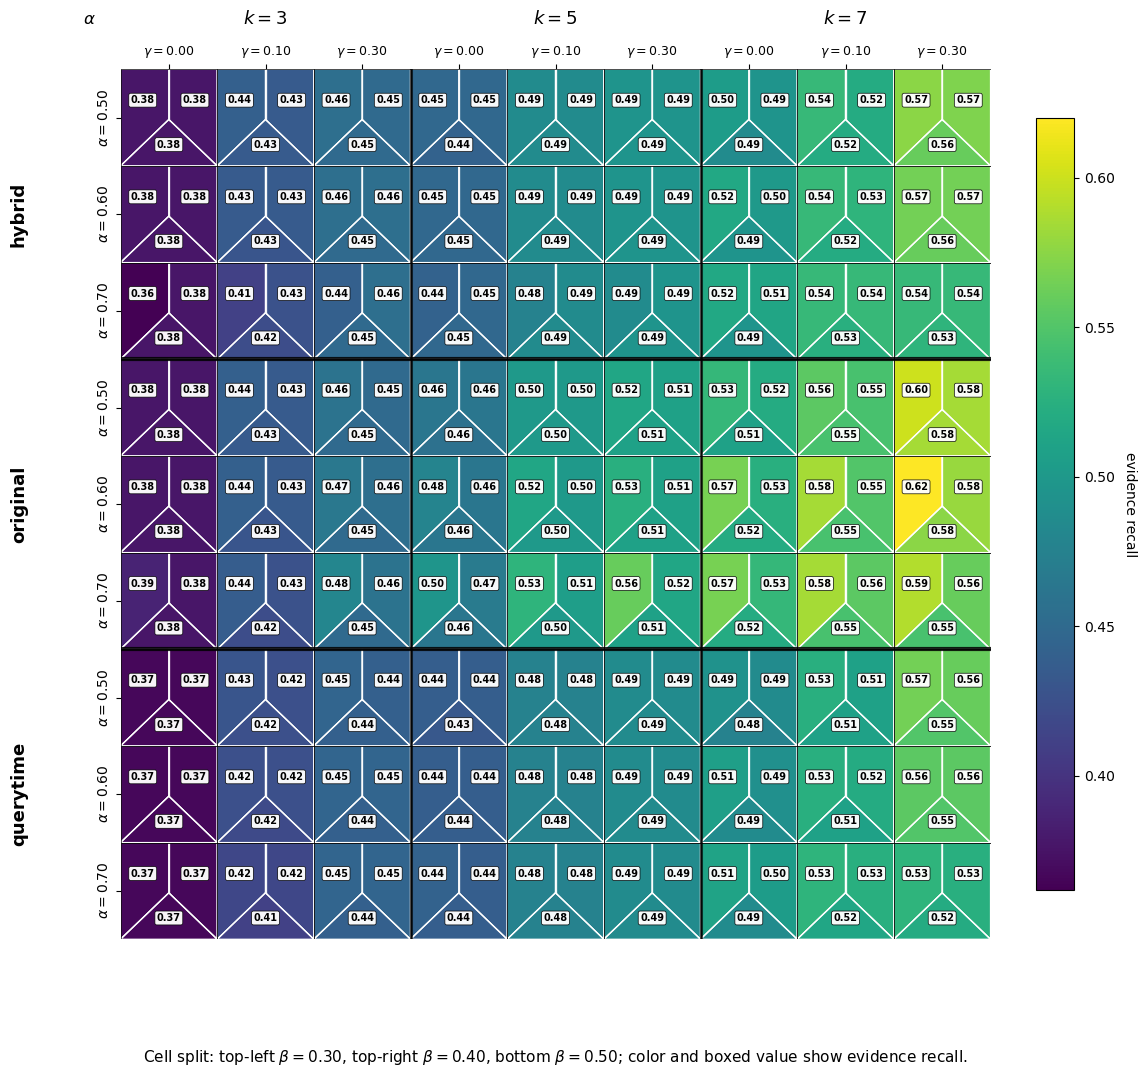

Saved PNG: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\grid_visualizations\grid_all_243_final_clean_labels_evidence_recall.png
Saved PDF: C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\grid_visualizations\grid_all_243_final_clean_labels_evidence_recall.pdf


In [19]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


# ============================================================
# CONFIG
# ============================================================

INPUT_CSV = Path(
    r"C:\Users\ivan\WORK\workshops\EMNLP\TimeBound\timebound_long_ablation_grid_outputs\retrieval_grid_summary.csv"
)

OUT_DIR = INPUT_CSV.parent / "grid_visualizations"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_KS = [3, 5, 7]
ALPHAS = [0.50, 0.60, 0.70]
BETAS = [0.30, 0.40, 0.50]
GAMMAS = [0.00, 0.10, 0.30]

METRIC = "evidence_recall"
CMAP = "viridis"

OUT_PNG = OUT_DIR / f"grid_all_243_final_clean_labels_{METRIC}.png"
OUT_PDF = OUT_DIR / f"grid_all_243_final_clean_labels_{METRIC}.pdf"


# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(INPUT_CSV).copy()

for col in ["alpha", "beta", "gamma"]:
    df[col] = df[col].astype(float).round(2)

df["top_k"] = df["top_k"].astype(int)

required = ["policy", "top_k", "alpha", "beta", "gamma", METRIC]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

preferred_policy_order = ["hybrid", "original", "querytime"]
available = df["policy"].dropna().unique().tolist()

policies = [p for p in preferred_policy_order if p in available]
policies += [p for p in sorted(available) if p not in policies]

print("Loaded all rows:", df.shape)
print("Policies:", policies)
print("Expected configurations:", len(policies) * len(TOP_KS) * len(ALPHAS) * len(BETAS) * len(GAMMAS))


# ============================================================
# GRID
# Rows: policy × alpha
# Columns: top_k × gamma
# Cell split:
#   top-left  beta=0.30
#   top-right beta=0.40
#   bottom    beta=0.50
# ============================================================

row_keys = [(policy, alpha) for policy in policies for alpha in ALPHAS]
col_keys = [(top_k, gamma) for top_k in TOP_KS for gamma in GAMMAS]

lookup = {}

for _, r in df.iterrows():
    key = (
        str(r["policy"]),
        int(r["top_k"]),
        round(float(r["alpha"]), 2),
        round(float(r["beta"]), 2),
        round(float(r["gamma"]), 2),
    )
    lookup[key] = r


vals = []
for policy, alpha in row_keys:
    for top_k, gamma in col_keys:
        for beta in BETAS:
            key = (policy, top_k, alpha, beta, gamma)
            if key in lookup:
                vals.append(float(lookup[key][METRIC]))

if not vals:
    raise ValueError("No matching grid values found.")

norm = Normalize(vmin=min(vals), vmax=max(vals))
cmap = plt.get_cmap(CMAP)

print("Metric range:", METRIC, min(vals), max(vals))


# ============================================================
# DRAW HELPERS
# ============================================================

def metric_value(policy, top_k, alpha, beta, gamma):
    key = (policy, top_k, alpha, beta, gamma)
    if key not in lookup:
        return None
    return float(lookup[key][METRIC])


def draw_metric_label(ax, x, y, value, fontsize=7.0):
    ax.text(
        x,
        y,
        f"{value:.2f}",
        ha="center",
        va="center",
        fontsize=fontsize,
        color="black",
        fontweight="bold",
        zorder=10,
        bbox=dict(
            boxstyle="round,pad=0.20",
            facecolor="white",
            edgecolor="black",
            linewidth=0.50,
            alpha=0.96,
        ),
    )


def draw_three_part_cell(ax, cx, cy, policy, top_k, alpha, gamma):
    left = cx - 0.5
    right = cx + 0.5
    top = cy - 0.5
    bottom = cy + 0.5

    pivot = (cx, cy + 0.02)

    regions = [
        {
            "beta": BETAS[0],
            "points": [(left, top), (cx, top), pivot, (left, bottom)],
            "label_xy": (cx - 0.27, cy - 0.18),
        },
        {
            "beta": BETAS[1],
            "points": [(cx, top), (right, top), (right, bottom), pivot],
            "label_xy": (cx + 0.27, cy - 0.18),
        },
        {
            "beta": BETAS[2],
            "points": [(left, bottom), (right, bottom), pivot],
            "label_xy": (cx, cy + 0.28),
        },
    ]

    for region in regions:
        beta = region["beta"]
        val = metric_value(policy, top_k, alpha, beta, gamma)

        face = "#e6e6e6" if val is None else cmap(norm(val))

        poly = Polygon(
            region["points"],
            closed=True,
            facecolor=face,
            edgecolor="white",
            linewidth=0.90,
            zorder=4,
        )
        ax.add_patch(poly)

        if val is not None:
            draw_metric_label(
                ax,
                region["label_xy"][0],
                region["label_xy"][1],
                val,
            )

    # Outer border
    border = Polygon(
        [(left, top), (right, top), (right, bottom), (left, bottom)],
        closed=True,
        facecolor="none",
        edgecolor="black",
        linewidth=0.55,
        alpha=0.65,
        zorder=11,
    )
    ax.add_patch(border)

    # Internal split lines
    ax.plot(
        [cx, cx],
        [top, pivot[1]],
        color="white",
        linewidth=0.95,
        alpha=0.95,
        zorder=9,
    )
    ax.plot(
        [left, pivot[0]],
        [bottom, pivot[1]],
        color="white",
        linewidth=0.95,
        alpha=0.95,
        zorder=9,
    )
    ax.plot(
        [right, pivot[0]],
        [bottom, pivot[1]],
        color="white",
        linewidth=0.95,
        alpha=0.95,
        zorder=9,
    )


# ============================================================
# PLOT
# ============================================================

fig_w = 13.8
fig_h = 10.8

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

ax.set_xlim(-0.5, len(col_keys) - 0.5)
ax.set_ylim(len(row_keys) - 0.5, -0.5)
ax.set_aspect("equal")


# Draw all cells
for i, (policy, alpha) in enumerate(row_keys):
    for j, (top_k, gamma) in enumerate(col_keys):
        draw_three_part_cell(
            ax=ax,
            cx=j,
            cy=i,
            policy=policy,
            top_k=top_k,
            alpha=alpha,
            gamma=gamma,
        )


# ============================================================
# SEPARATORS
# ============================================================

rows_per_policy = len(ALPHAS)
cols_per_k = len(GAMMAS)

# Policy block separators
for y in [rows_per_policy - 0.5, 2 * rows_per_policy - 0.5]:
    ax.axhline(y, linewidth=3.0, color="black", alpha=0.85, zorder=12)

# Thin row separators
for y in np.arange(-0.5, len(row_keys), 1):
    ax.axhline(y, linewidth=0.65, color="black", alpha=0.35, zorder=12)

# k-block separators
for x in [cols_per_k - 0.5, 2 * cols_per_k - 0.5]:
    ax.axvline(x, linewidth=2.2, color="black", alpha=0.70, zorder=12)

# Thin column separators
for x in np.arange(-0.5, len(col_keys), 1):
    ax.axvline(x, linewidth=0.65, color="black", alpha=0.35, zorder=12)


# ============================================================
# AXIS LABELS: CLEAN, NO REPEATED POLICY/K
# ============================================================

# X-axis: only gamma repeated within k-blocks
ax.set_xticks(np.arange(len(col_keys)))
ax.set_xticklabels(
    [f"$\\gamma={gamma:.2f}$" for _, gamma in col_keys],
    fontsize=9,
)

# Y-axis: alpha only, but rotated vertically
ax.set_yticks(np.arange(len(row_keys)))
ax.set_yticklabels(
    [f"$\\alpha={alpha:.2f}$" for _, alpha in row_keys],
    fontsize=10,
    rotation=90,
    va="center",
)

ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)


# Top group labels for k blocks: once per block
for k_idx, top_k in enumerate(TOP_KS):
    start = k_idx * cols_per_k
    end = start + cols_per_k - 1
    center = (start + end) / 2

    ax.text(
        center,
        -1.02,
        f"$k={top_k}$",
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        transform=ax.transData,
        clip_on=False,
    )


# Left group labels for policy blocks: once per policy block, rotated
for p_idx, policy in enumerate(policies):
    start = p_idx * rows_per_policy
    end = start + rows_per_policy - 1
    center = (start + end) / 2

    ax.text(
        -1.55,
        center,
        policy,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        rotation=90,
        transform=ax.transData,
        clip_on=False,
    )


# Small left header for alpha column
ax.text(
    -0.82,
    -1.02,
    "$\\alpha$",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    transform=ax.transData,
    clip_on=False,
)



ax.text(
    0.5,
    -0.125,
    legend_text,
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=11,
)




# Shared colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, fraction=0.030, pad=0.035)
cbar.set_label(METRIC.replace("_", " "), rotation=270, labelpad=16)


for spine in ax.spines.values():
    spine.set_visible(False)


plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")

plt.show()

print("Saved PNG:", OUT_PNG)
print("Saved PDF:", OUT_PDF)

# Другие датасеты

In [20]:
from pathlib import Path
import json
import pandas as pd
from collections import Counter


# ============================================================
# EXTERNAL OUTPUT FOLDERS
# ============================================================

FOLDERS = {
    "tempreason": Path(r"D:\Users\TimeBound\external_llm_outputs_standalone\tempreason"),
    "tcp": Path(r"D:\Users\TimeBound\external_llm_outputs_parallel_complextr_tcp\tcp"),
    "complextr": Path(r"D:\Users\TimeBound\external_llm_outputs_parallel_complextr_tcp\complextr"),
    "locomo_pilot": Path(r"D:\Users\TimeBound\external_llm_outputs_parallel_locomo"),
    "locomo_500": Path(r"D:\Users\TimeBound\external_llm_outputs_parallel_locomo_500"),
}


KEY_PATTERNS = [
    "summary",
    "by_task",
    "by_category",
    "by_difficulty",
    "metrics",
    "failure",
    "relaxed",
]


# ============================================================
# HELPERS
# ============================================================

def human_size(n):
    n = float(n)
    units = ["B", "KB", "MB", "GB", "TB"]
    i = 0
    while n >= 1024 and i < len(units) - 1:
        n /= 1024
        i += 1
    return f"{n:.1f} {units[i]}"


def count_jsonl(path: Path, max_bad_show=3):
    n = 0
    bad = 0
    sample = []

    if not path.exists():
        return {"exists": False, "n": 0, "bad": 0, "sample": []}

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                obj = json.loads(line)
                n += 1
                if len(sample) < 2:
                    sample.append(obj)
            except Exception:
                bad += 1
                if bad <= max_bad_show:
                    print("BAD JSONL LINE:", path, line[:200])

    return {"exists": True, "n": n, "bad": bad, "sample": sample}


def is_key_file(p: Path):
    name = p.name.lower()
    return (
        p.suffix.lower() in {".csv", ".json", ".jsonl"}
        and any(k in name for k in KEY_PATTERNS + ["predictions"])
    )


def preview_json(path: Path, max_chars=1200):
    try:
        with path.open("r", encoding="utf-8", errors="ignore") as f:
            obj = json.load(f)

        if isinstance(obj, dict):
            print("JSON TYPE: dict")
            print("JSON KEYS:", list(obj.keys())[:50])
            print(json.dumps(obj, ensure_ascii=False, indent=2)[:max_chars])
        elif isinstance(obj, list):
            print("JSON TYPE: list")
            print("LIST LEN:", len(obj))
            if obj:
                print("FIRST ITEM:")
                print(json.dumps(obj[0], ensure_ascii=False, indent=2)[:max_chars])
        else:
            print("JSON TYPE:", type(obj).__name__)
            print(str(obj)[:max_chars])

    except Exception as e:
        print("JSON READ ERROR:", e)


def preview_csv(path: Path, n=5):
    try:
        df = pd.read_csv(path)
        print("SHAPE:", df.shape)
        print("COLUMNS:", list(df.columns))
        print("HEAD:")
        print(df.head(n).to_string(index=False))
    except Exception as e:
        print("CSV READ ERROR:", e)


def preview_jsonl(path: Path):
    info = count_jsonl(path)
    print(f"JSONL COUNT: {info['n']} | BAD: {info['bad']}")

    if info["sample"]:
        first = info["sample"][0]
        print("FIRST ITEM KEYS:", list(first.keys())[:80] if isinstance(first, dict) else type(first).__name__)
        if isinstance(first, dict):
            print("FIRST ITEM PREVIEW:")
            print(json.dumps({k: first.get(k) for k in list(first.keys())[:20]}, ensure_ascii=False, indent=2)[:1500])


# ============================================================
# MAIN SCAN
# ============================================================

all_inventory_rows = []

for dataset, root in FOLDERS.items():
    print("\n" + "=" * 150)
    print("DATASET:", dataset)
    print("FOLDER:", root)
    print("=" * 150)

    if not root.exists():
        print("MISSING")
        continue

    files = sorted([p for p in root.rglob("*") if p.is_file()])
    dirs = sorted([p for p in root.iterdir() if p.is_dir()])

    print("\nTOP-LEVEL DIRECTORIES / MODES:")
    for d in dirs:
        print("  DIR ", d.name)

    print("\nTOP-LEVEL FILES:")
    for p in sorted([p for p in root.iterdir() if p.is_file()]):
        print(f"  FILE {p.name:60s} {human_size(p.stat().st_size)}")

    ext_counts = Counter(p.suffix.lower() if p.suffix else "<no ext>" for p in files)
    ext_sizes = Counter()
    for p in files:
        ext = p.suffix.lower() if p.suffix else "<no ext>"
        ext_sizes[ext] += p.stat().st_size

    print("\nEXTENSION SUMMARY:")
    for ext, cnt in ext_counts.most_common():
        print(f"  {ext:10s} {cnt:5d} files   {human_size(ext_sizes[ext])}")

    print("\nPREDICTIONS BY MODE:")
    for mode_dir in dirs:
        pred_path = mode_dir / "predictions.jsonl"
        if pred_path.exists():
            info = count_jsonl(pred_path)
            print(f"  {mode_dir.name:20s} n={info['n']:6d} bad={info['bad']:3d} size={human_size(pred_path.stat().st_size)}")
            all_inventory_rows.append({
                "dataset": dataset,
                "mode": mode_dir.name,
                "file_type": "predictions",
                "path": str(pred_path),
                "n_rows": info["n"],
                "bad_rows": info["bad"],
                "size": pred_path.stat().st_size,
            })

    key_files = [p for p in files if is_key_file(p)]
    key_files = sorted(key_files, key=lambda p: (p.parent.as_posix(), p.name.lower()))

    print("\nKEY FILES:")
    for p in key_files:
        rel = p.relative_to(root)
        print(f"  {str(rel):90s} {human_size(p.stat().st_size)}")
        all_inventory_rows.append({
            "dataset": dataset,
            "mode": p.parent.name if p.parent != root else "",
            "file_type": p.suffix.lower(),
            "path": str(p),
            "n_rows": None,
            "bad_rows": None,
            "size": p.stat().st_size,
        })

    print("\n" + "-" * 150)
    print("DETAILED PREVIEW OF KEY CSV/JSON SUMMARY FILES")
    print("-" * 150)

    for p in key_files:
        rel = p.relative_to(root)
        name = p.name.lower()

        # skip huge raw predictions preview except count
        if name == "predictions.jsonl":
            print("\n" + "-" * 120)
            print("FILE:", rel)
            preview_jsonl(p)
            continue

        if p.suffix.lower() not in {".csv", ".json"}:
            continue

        print("\n" + "-" * 120)
        print("FILE:", rel)
        print("SIZE:", human_size(p.stat().st_size))

        if p.suffix.lower() == ".csv":
            preview_csv(p)
        elif p.suffix.lower() == ".json":
            preview_json(p)


# ============================================================
# SAVE INVENTORY
# ============================================================

OUT = Path(r"D:\Users\TimeBound\external_outputs_inventory.csv")
inv = pd.DataFrame(all_inventory_rows)
inv.to_csv(OUT, index=False, encoding="utf-8")

print("\n" + "=" * 150)
print("INVENTORY SAVED")
print("=" * 150)
print(OUT)
print(inv.head(30).to_string(index=False))


DATASET: tempreason
FOLDER: D:\Users\TimeBound\external_llm_outputs_standalone\tempreason

TOP-LEVEL DIRECTORIES / MODES:
  DIR  full_history
  DIR  oracle_evidence
  DIR  semantic_rag
  DIR  timebound_rag

TOP-LEVEL FILES:
  FILE tempreason_bad_examples_sample.csv                           7.1 KB
  FILE tempreason_summary_recomputed.csv                            752.0 B

EXTENSION SUMMARY:
  .jsonl         8 files   27.0 MB
  .csv           2 files   7.9 KB

PREDICTIONS BY MODE:
  full_history         n= 10000 bad=  0 size=7.2 MB
  oracle_evidence      n=  6919 bad=  0 size=5.0 MB
  semantic_rag         n= 10000 bad=  0 size=7.2 MB
  timebound_rag        n= 10000 bad=  0 size=7.2 MB

KEY FILES:
  tempreason_summary_recomputed.csv                                                          752.0 B
  full_history\predictions.jsonl                                                             7.2 MB
  oracle_evidence\predictions.jsonl                                                         

In [21]:
from pathlib import Path
import json
import pandas as pd


# ============================================================
# PATHS
# ============================================================

ROOT = Path(r"D:\Users\TimeBound")

FOLDERS = {
    "tempreason": ROOT / "external_llm_outputs_standalone" / "tempreason",
    "tcp": ROOT / "external_llm_outputs_parallel_complextr_tcp" / "tcp",
    "complextr": ROOT / "external_llm_outputs_parallel_complextr_tcp" / "complextr",
    "locomo_pilot": ROOT / "external_llm_outputs_parallel_locomo",
    "locomo_500": ROOT / "external_llm_outputs_parallel_locomo_500",
}

OUT_DIR = ROOT / "external_final_tables"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODES_ORDER = [
    "full_history",
    "semantic_rag",
    "timebound_rag",
    "oracle_evidence",
]

DATASET_ORDER = [
    "tempreason",
    "complextr",
    "tcp",
    "locomo_pilot",
    "locomo_500",
]


# ============================================================
# HELPERS
# ============================================================

def read_jsonl(path: Path):
    rows = []
    if not path.exists():
        return rows

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except Exception:
                pass

    return rows


def read_csv_safe(path: Path):
    if not path.exists():
        print("Missing:", path)
        return pd.DataFrame()
    return pd.read_csv(path)


def evidence_f1_from_turns(pred, gold):
    p = set(pred or [])
    g = set(gold or [])

    if not p and not g:
        return 1.0
    if not p or not g:
        return 0.0

    tp = len(p & g)
    prec = tp / len(p)
    rec = tp / len(g)

    if prec + rec == 0:
        return 0.0

    return 2 * prec * rec / (prec + rec)


def summarize_predictions(dataset_name: str, mode: str, pred_path: Path):
    rows = read_jsonl(pred_path)

    if not rows:
        return None

    n = len(rows)

    llm_ok = [bool(r.get("llm_ok", False)) for r in rows]
    strict = [bool(r.get("strict_correct", False)) for r in rows]
    relaxed = [bool(r.get("relaxed_correct", False)) for r in rows]

    ev_f1 = []
    for r in rows:
        if "evidence_f1" in r and r.get("evidence_f1") is not None:
            try:
                ev_f1.append(float(r.get("evidence_f1")))
            except Exception:
                ev_f1.append(0.0)
        else:
            ev_f1.append(
                evidence_f1_from_turns(
                    r.get("predicted_evidence_turns", []),
                    r.get("gold_evidence_turns", []),
                )
            )

    return {
        "dataset": dataset_name,
        "mode": mode,
        "n_examples": n,
        "llm_success_rate": sum(llm_ok) / n if n else 0.0,
        "strict_accuracy": sum(strict) / n if n else 0.0,
        "relaxed_accuracy": sum(relaxed) / n if n else 0.0,
        "evidence_f1": sum(ev_f1) / n if n else 0.0,
        "predictions_path": str(pred_path),
        "is_partial": False,
    }


def collect_prediction_summaries(dataset_name: str, folder: Path):
    out = []

    for mode in MODES_ORDER:
        pred_path = folder / mode / "predictions.jsonl"

        if pred_path.exists():
            s = summarize_predictions(dataset_name, mode, pred_path)
            if s:
                out.append(s)

    return pd.DataFrame(out)


def round_df(df, ndigits=3):
    out = df.copy()
    for c in out.columns:
        if pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].round(ndigits)
    return out


def mode_label(mode):
    return {
        "full_history": "Full history",
        "semantic_rag": "Semantic RAG",
        "timebound_rag": "TimeBound-RAG",
        "oracle_evidence": "Oracle evidence",
    }.get(mode, mode)


def dataset_label(dataset):
    return {
        "tempreason": "TempReason",
        "complextr": "Complex-TR",
        "tcp": "TCP",
        "locomo_pilot": "LoCoMo pilot",
        "locomo_500": "LoCoMo-500",
    }.get(dataset, dataset)


def dataset_role(dataset):
    return {
        "tempreason": "Temporal arithmetic sanity check",
        "complextr": "Compact interval temporal QA",
        "tcp": "Constraint scheduling / planning boundary case",
        "locomo_pilot": "Long-memory full-history pilot",
        "locomo_500": "Long-memory retrieval diagnostic",
    }.get(dataset, "")


def dataset_implication(dataset):
    return {
        "tempreason": (
            "Retrieval is largely irrelevant: all non-oracle modes reach about 0.94--0.95 relaxed accuracy; "
            "the task mainly tests date arithmetic and answer normalization."
        ),
        "complextr": (
            "Compact interval facts leave limited room for temporal retrieval gains; "
            "full-history/oracle are strongest, while Semantic RAG and TimeBound-RAG are close."
        ),
        "tcp": (
            "Sparse RAG is harmful because project completion requires many interacting constraints; "
            "full-history is much better than retrieved top-k contexts."
        ),
        "locomo_pilot": (
            "Full-history pilot shows that the reader can solve a substantial fraction of long-memory QA, "
            "but the run is partial and expensive."
        ),
        "locomo_500": (
            "Oracle evidence is much stronger than RAG, showing a severe retrieval bottleneck; "
            "current TimeBound scoring does not improve over Semantic RAG because LoCoMo lacks explicit temporal state transitions."
        ),
    }.get(dataset, "")


# ============================================================
# 1. COLLECT DATASET SUMMARIES
# ============================================================

summary_frames = []

# TempReason: use recomputed summary if available
tempreason_summary_path = FOLDERS["tempreason"] / "tempreason_summary_recomputed.csv"
tempreason_df = read_csv_safe(tempreason_summary_path)

if not tempreason_df.empty:
    # Use currently visible predictions count for oracle if the summary is stale.
    # If predictions have 6919 but summary says 6222, recompute from predictions.
    recomputed_temp = collect_prediction_summaries("tempreason", FOLDERS["tempreason"])

    if not recomputed_temp.empty:
        tempreason_df = recomputed_temp
    else:
        tempreason_df["is_partial"] = tempreason_df.get("is_partial", False)

    summary_frames.append(tempreason_df)
else:
    summary_frames.append(collect_prediction_summaries("tempreason", FOLDERS["tempreason"]))


# TCP and Complex-TR: compute from predictions
summary_frames.append(collect_prediction_summaries("tcp", FOLDERS["tcp"]))
summary_frames.append(collect_prediction_summaries("complextr", FOLDERS["complextr"]))


# LoCoMo pilot: can use csv, but recompute is safer
summary_frames.append(collect_prediction_summaries("locomo_pilot", FOLDERS["locomo_pilot"]))


# LoCoMo-500
summary_frames.append(collect_prediction_summaries("locomo_500", FOLDERS["locomo_500"]))


all_summary = pd.concat(
    [df for df in summary_frames if df is not None and not df.empty],
    ignore_index=True,
)

all_summary["dataset_label"] = all_summary["dataset"].map(dataset_label)
all_summary["method"] = all_summary["mode"].map(mode_label)
all_summary["dataset_role"] = all_summary["dataset"].map(dataset_role)
all_summary["main_implication"] = all_summary["dataset"].map(dataset_implication)

# Mark partial runs
all_summary["is_partial"] = all_summary.get("is_partial", False)
all_summary.loc[all_summary["dataset"] == "locomo_pilot", "is_partial"] = True
all_summary.loc[
    (all_summary["dataset"] == "tempreason") & (all_summary["mode"] == "oracle_evidence"),
    "is_partial"
] = True

# Sort
all_summary["dataset_order"] = all_summary["dataset"].map({d: i for i, d in enumerate(DATASET_ORDER)})
all_summary["mode_order"] = all_summary["mode"].map({m: i for i, m in enumerate(MODES_ORDER)})
all_summary = all_summary.sort_values(["dataset_order", "mode_order"]).reset_index(drop=True)

cols = [
    "dataset",
    "dataset_label",
    "dataset_role",
    "mode",
    "method",
    "n_examples",
    "llm_success_rate",
    "strict_accuracy",
    "relaxed_accuracy",
    "evidence_f1",
    "is_partial",
    "main_implication",
    "predictions_path",
]

all_summary = all_summary[[c for c in cols if c in all_summary.columns]]
all_summary_rounded = round_df(all_summary)

all_summary_path = OUT_DIR / "external_all_summary_long.csv"
all_summary_rounded.to_csv(all_summary_path, index=False, encoding="utf-8")

print("=" * 120)
print("EXTERNAL ALL SUMMARY")
print("=" * 120)
print(all_summary_rounded.to_string(index=False))
print("\nSaved:", all_summary_path)


# ============================================================
# 2. WIDE TABLE FOR PAPER
# Dataset | Role | n | full | semantic | timebound | oracle | implication
# ============================================================

metric = "relaxed_accuracy"

wide = all_summary.pivot_table(
    index=["dataset", "dataset_label", "dataset_role"],
    columns="mode",
    values=metric,
    aggfunc="first",
).reset_index()

for mode in MODES_ORDER:
    if mode not in wide.columns:
        wide[mode] = None

# n examples by mode
n_wide = all_summary.pivot_table(
    index=["dataset"],
    columns="mode",
    values="n_examples",
    aggfunc="first",
).reset_index()

n_wide = n_wide.rename(columns={m: f"n_{m}" for m in MODES_ORDER if m in n_wide.columns})
wide = wide.merge(n_wide, on="dataset", how="left")

wide["main_implication"] = wide["dataset"].map(dataset_implication)

wide = wide[
    [
        "dataset",
        "dataset_label",
        "dataset_role",
        "n_full_history",
        "n_semantic_rag",
        "n_timebound_rag",
        "n_oracle_evidence",
        "full_history",
        "semantic_rag",
        "timebound_rag",
        "oracle_evidence",
        "main_implication",
    ]
]

wide["delta_timebound_minus_semantic"] = wide["timebound_rag"] - wide["semantic_rag"]
wide["oracle_gap_vs_timebound"] = wide["oracle_evidence"] - wide["timebound_rag"]

# Reorder deltas near metrics
wide = wide[
    [
        "dataset",
        "dataset_label",
        "dataset_role",
        "n_full_history",
        "n_semantic_rag",
        "n_timebound_rag",
        "n_oracle_evidence",
        "full_history",
        "semantic_rag",
        "timebound_rag",
        "delta_timebound_minus_semantic",
        "oracle_evidence",
        "oracle_gap_vs_timebound",
        "main_implication",
    ]
]

wide["dataset_order"] = wide["dataset"].map({d: i for i, d in enumerate(DATASET_ORDER)})
wide = wide.sort_values("dataset_order").drop(columns=["dataset_order"])

wide_rounded = round_df(wide)

wide_path = OUT_DIR / "external_paper_wide_relaxed_accuracy.csv"
wide_rounded.to_csv(wide_path, index=False, encoding="utf-8")

print("\n" + "=" * 120)
print("EXTERNAL PAPER WIDE TABLE, RELAXED ACCURACY")
print("=" * 120)
print(wide_rounded.to_string(index=False))
print("\nSaved:", wide_path)


# ============================================================
# 3. EVIDENCE F1 WIDE TABLE
# ============================================================

ev_wide = all_summary.pivot_table(
    index=["dataset", "dataset_label", "dataset_role"],
    columns="mode",
    values="evidence_f1",
    aggfunc="first",
).reset_index()

for mode in MODES_ORDER:
    if mode not in ev_wide.columns:
        ev_wide[mode] = None

ev_wide["delta_timebound_minus_semantic"] = ev_wide["timebound_rag"] - ev_wide["semantic_rag"]
ev_wide["oracle_gap_vs_timebound"] = ev_wide["oracle_evidence"] - ev_wide["timebound_rag"]

ev_wide["dataset_order"] = ev_wide["dataset"].map({d: i for i, d in enumerate(DATASET_ORDER)})
ev_wide = ev_wide.sort_values("dataset_order").drop(columns=["dataset_order"])
ev_wide_rounded = round_df(ev_wide)

ev_wide_path = OUT_DIR / "external_paper_wide_evidence_f1.csv"
ev_wide_rounded.to_csv(ev_wide_path, index=False, encoding="utf-8")

print("\n" + "=" * 120)
print("EXTERNAL PAPER WIDE TABLE, EVIDENCE F1")
print("=" * 120)
print(ev_wide_rounded.to_string(index=False))
print("\nSaved:", ev_wide_path)


# ============================================================
# 4. LOCOMO CATEGORY TABLE
# ============================================================

locomo_cat_frames = []

pilot_cat_path = FOLDERS["locomo_pilot"] / "locomo_summary_by_category.csv"
pilot_cat = read_csv_safe(pilot_cat_path)
if not pilot_cat.empty:
    pilot_cat.insert(0, "dataset", "locomo_pilot")
    locomo_cat_frames.append(pilot_cat)

locomo500_cat_path = FOLDERS["locomo_500"] / "locomo_summary_by_category.csv"
locomo500_cat = read_csv_safe(locomo500_cat_path)
if not locomo500_cat.empty:
    locomo500_cat.insert(0, "dataset", "locomo_500")
    locomo_cat_frames.append(locomo500_cat)

if locomo_cat_frames:
    locomo_cat = pd.concat(locomo_cat_frames, ignore_index=True)
    locomo_cat["dataset_label"] = locomo_cat["dataset"].map(dataset_label)
    locomo_cat["method"] = locomo_cat["mode"].map(mode_label)
    locomo_cat = round_df(locomo_cat)

    locomo_cat_path = OUT_DIR / "external_locomo_by_category.csv"
    locomo_cat.to_csv(locomo_cat_path, index=False, encoding="utf-8")

    print("\n" + "=" * 120)
    print("LOCOMO BY CATEGORY")
    print("=" * 120)
    print(locomo_cat.to_string(index=False))
    print("\nSaved:", locomo_cat_path)
else:
    locomo_cat = pd.DataFrame()


# ============================================================
# 5. LATEX-FRIENDLY COMPACT TABLE
# ============================================================

latex_compact = wide_rounded.copy()

latex_compact = latex_compact.rename(columns={
    "dataset_label": "Dataset",
    "dataset_role": "Role",
    "n_full_history": "$n_{full}$",
    "n_semantic_rag": "$n_{sem}$",
    "n_timebound_rag": "$n_{tb}$",
    "n_oracle_evidence": "$n_{oracle}$",
    "full_history": "Full",
    "semantic_rag": "SemRAG",
    "timebound_rag": "TimeBound",
    "delta_timebound_minus_semantic": "$\\Delta$TB-Sem",
    "oracle_evidence": "Oracle",
    "oracle_gap_vs_timebound": "Oracle-TB",
    "main_implication": "Interpretation",
})

latex_compact = latex_compact.drop(columns=["dataset"], errors="ignore")

latex_path = OUT_DIR / "external_latex_compact_table.tex"

latex_str = latex_compact.to_latex(
    index=False,
    escape=False,
    column_format="llrrrrrrrrrl",
    float_format=lambda x: f"{x:.3f}",
)

with latex_path.open("w", encoding="utf-8") as f:
    f.write(latex_str)

print("\n" + "=" * 120)
print("LATEX TABLE SAVED")
print("=" * 120)
print(latex_path)
print(latex_str[:3000])


# ============================================================
# 6. EXCEL WORKBOOK
# ============================================================

xlsx_path = OUT_DIR / "external_final_tables.xlsx"

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    all_summary_rounded.to_excel(writer, sheet_name="all_summary_long", index=False)
    wide_rounded.to_excel(writer, sheet_name="wide_relaxed", index=False)
    ev_wide_rounded.to_excel(writer, sheet_name="wide_evidence_f1", index=False)

    if not locomo_cat.empty:
        locomo_cat.to_excel(writer, sheet_name="locomo_by_category", index=False)

    latex_compact.to_excel(writer, sheet_name="latex_compact_source", index=False)

print("\n" + "=" * 120)
print("DONE")
print("=" * 120)
print("Output dir:", OUT_DIR)
print("Excel:", xlsx_path)

EXTERNAL ALL SUMMARY
     dataset dataset_label                                   dataset_role            mode          method  n_examples  llm_success_rate  strict_accuracy  relaxed_accuracy  evidence_f1  is_partial                                                                                                                                                                                         main_implication                                                                                           predictions_path
  tempreason    TempReason               Temporal arithmetic sanity check    full_history    Full history       10000              1.00            0.453             0.956        1.000       False                                           Retrieval is largely irrelevant: all non-oracle modes reach about 0.94--0.95 relaxed accuracy; the task mainly tests date arithmetic and answer normalization.               D:\Users\TimeBound\external_llm_outputs_standalone\tempreason\fu

# Data stat

In [22]:
from pathlib import Path
import json
import re
import pandas as pd
from collections import Counter


# ============================================================
# PATHS
# ============================================================

ROOT = Path(r"D:\Users\TimeBound")

TEMPREASON_DIR = ROOT / "TempReason"
COMPLEXTR_DIR = ROOT / "complex-tr"
TCP_DIR = ROOT / "TCP"

LOCOMO_PATH = ROOT / "locomo" / "data" / "locomo10.json"
LOCOMO_CONVERTED_PATH = ROOT / "converted_external_selected" / "locomo_timebound.jsonl"

SHORT_DIR = ROOT / "synthetic"

# Try several known short names.
SHORT_CANDIDATES = [
    SHORT_DIR / "timebound_synthetic_openai.jsonl",
    SHORT_DIR / "timebound_synthetic.jsonl",
    SHORT_DIR / "timebound_synthetic_recovered.jsonl",
]

LONG_PATH = ROOT / "synthetic" / "timebound_long.jsonl"

OUT_DIR = ROOT / "dataset_overview_tables"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# HELPERS
# ============================================================

def human_size(n: int) -> str:
    n = float(n)
    units = ["B", "KB", "MB", "GB", "TB"]
    i = 0
    while n >= 1024 and i < len(units) - 1:
        n /= 1024
        i += 1
    return f"{n:.1f} {units[i]}"


def count_jsonl(path: Path, limit=None):
    n = 0
    bad = 0
    first = None

    if not path.exists():
        return {"exists": False, "n": 0, "bad": 0, "first": None}

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if limit is not None and n >= limit:
                break

            line = line.strip()
            if not line:
                continue

            try:
                obj = json.loads(line)
                if first is None:
                    first = obj
                n += 1
            except Exception:
                bad += 1

    return {"exists": True, "n": n, "bad": bad, "first": first}


def load_jsonl_sample(path: Path, max_rows=None):
    rows = []

    if not path.exists():
        return rows

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if max_rows is not None and len(rows) >= max_rows:
                break

            line = line.strip()
            if not line:
                continue

            try:
                rows.append(json.loads(line))
            except Exception:
                pass

    return rows


def load_json_lines_sample(path: Path, max_rows=None):
    """
    For files with .json extension but JSONL-like content.
    """
    return load_jsonl_sample(path, max_rows=max_rows)


def safe_json_load(path: Path):
    try:
        with path.open("r", encoding="utf-8", errors="ignore") as f:
            return json.load(f)
    except Exception:
        return None


def short_text(x, max_len=180):
    s = str(x).replace("\n", " ").strip()
    s = re.sub(r"\s+", " ", s)
    if len(s) > max_len:
        return s[:max_len - 3] + "..."
    return s


def get_short_path():
    for p in SHORT_CANDIDATES:
        if p.exists():
            return p

    # fallback: largest jsonl in synthetic except errors/logs
    candidates = [
        p for p in SHORT_DIR.glob("*.jsonl")
        if "error" not in p.name.lower() and "pred" not in p.name.lower()
    ]

    if candidates:
        return sorted(candidates, key=lambda x: x.stat().st_size, reverse=True)[0]

    return SHORT_CANDIDATES[0]


def summarize_task_distribution(rows, key="task_type", max_items=8):
    c = Counter()
    for r in rows:
        val = r.get(key)
        if val is not None:
            c[str(val)] += 1

    if not c:
        return ""

    parts = [f"{k}: {v}" for k, v in c.most_common(max_items)]
    if len(c) > max_items:
        parts.append(f"+{len(c) - max_items} more")
    return "; ".join(parts)


def extract_timebound_example(row):
    if not row:
        return "", ""

    q = row.get("query", row.get("question", ""))
    a = row.get("gold_answer", row.get("answer", ""))

    return short_text(q), short_text(a)


def summarize_timebound_jsonl(name, path, role, temporal_signal, evidence_type):
    rows = load_jsonl_sample(path)

    n = len(rows)
    first = rows[0] if rows else {}

    task_dist = summarize_task_distribution(rows, "task_type")

    hist_lengths = []
    gold_evidence_lengths = []

    for r in rows:
        hist = r.get("history", [])
        if isinstance(hist, list):
            hist_lengths.append(len(hist))

        ev = r.get("gold_evidence_turns", [])
        if isinstance(ev, list):
            gold_evidence_lengths.append(len(ev))

    q, a = extract_timebound_example(first)

    return {
        "dataset": name,
        "source_path": str(path),
        "role_in_evaluation": role,
        "format": "TimeBound JSONL",
        "n_examples": n,
        "n_dialogues_or_records": "",
        "avg_history_turns": round(sum(hist_lengths) / len(hist_lengths), 2) if hist_lengths else "",
        "avg_gold_evidence_turns": round(sum(gold_evidence_lengths) / len(gold_evidence_lengths), 2) if gold_evidence_lengths else "",
        "task_or_category_distribution": task_dist,
        "evidence_annotation": evidence_type,
        "temporal_signal": temporal_signal,
        "example_query": q,
        "example_answer": a,
        "size": human_size(path.stat().st_size) if path.exists() else "missing",
    }


# ============================================================
# EXTERNAL DATASET SUMMARIZERS
# ============================================================

def summarize_tempreason():
    files = [
        TEMPREASON_DIR / "test_l1.json",
        TEMPREASON_DIR / "test_l1_future.json",
        TEMPREASON_DIR / "test_l2.json",
        TEMPREASON_DIR / "test_l3.json",
        TEMPREASON_DIR / "val_l1.json",
        TEMPREASON_DIR / "val_l2.json",
        TEMPREASON_DIR / "val_l3.json",
        TEMPREASON_DIR / "train_l1.json",
        TEMPREASON_DIR / "train_l2.json",
        TEMPREASON_DIR / "train_l3.json",
    ]

    existing = [p for p in files if p.exists()]

    counts = {}
    first = None
    total = 0
    total_size = 0

    for p in existing:
        info = count_jsonl(p)
        counts[p.name] = info["n"]
        total += info["n"]
        total_size += p.stat().st_size

        if first is None and info["first"] is not None:
            first = info["first"]

    q = short_text(first.get("question", "")) if first else ""
    ans = ""
    if first:
        ta = first.get("text_answers", {})
        if isinstance(ta, dict):
            ans = ta.get("text", [""])[0] if ta.get("text") else ""
        else:
            ans = first.get("answer", "")

    split_summary = "; ".join([f"{k}: {v}" for k, v in counts.items()])

    return {
        "dataset": "TempReason",
        "source_path": str(TEMPREASON_DIR),
        "role_in_evaluation": "External diagnostic for explicit temporal arithmetic",
        "format": "JSONL-like .json files",
        "n_examples": total,
        "n_dialogues_or_records": len(existing),
        "avg_history_turns": 1,
        "avg_gold_evidence_turns": 1,
        "task_or_category_distribution": short_text(split_summary, 300),
        "evidence_annotation": "Converted as single date/context evidence",
        "temporal_signal": "Date offsets, month/year arithmetic, future dates",
        "example_query": q,
        "example_answer": short_text(ans),
        "size": human_size(total_size),
    }


def summarize_complextr():
    # Main evaluated file was test_gold.json.
    path = COMPLEXTR_DIR / "test_gold.json"

    rows = load_jsonl_sample(path)
    n = len(rows)
    first = rows[0] if rows else {}

    fact_counts = []
    answer_lengths = []

    for r in rows:
        facts = r.get("facts")
        if isinstance(facts, list):
            fact_counts.append(len(facts))
        elif isinstance(r.get("fact_context"), str):
            fact_counts.append(len([x for x in r["fact_context"].split("\n") if x.strip()]))

        ans = r.get("text_answers", {}).get("text", [])
        if isinstance(ans, list):
            answer_lengths.append(len(ans))

    q = short_text(first.get("question", ""))
    ans_list = first.get("text_answers", {}).get("text", []) if first else []
    ans = "; ".join(map(str, ans_list)) if isinstance(ans_list, list) else str(ans_list)

    return {
        "dataset": "Complex-TR",
        "source_path": str(path),
        "role_in_evaluation": "External diagnostic for compact interval temporal QA",
        "format": "JSONL-like .json",
        "n_examples": n,
        "n_dialogues_or_records": n,
        "avg_history_turns": round(sum(fact_counts) / len(fact_counts), 2) if fact_counts else "",
        "avg_gold_evidence_turns": round(sum(fact_counts) / len(fact_counts), 2) if fact_counts else "",
        "task_or_category_distribution": "Interval fact selection over dated affiliations/roles",
        "evidence_annotation": "Fact context / converted fact turns",
        "temporal_signal": "Validity intervals with from/to dates",
        "example_query": q,
        "example_answer": short_text(ans),
        "size": human_size(path.stat().st_size) if path.exists() else "missing",
    }


def summarize_tcp():
    files = [
        TCP_DIR / "TCP_short.jsonl",
        TCP_DIR / "TCP_long.jsonl",
    ]

    existing = [p for p in files if p.exists()]
    total = 0
    total_size = 0
    first = None
    split_counts = {}

    task_counts = []
    agent_counts = []
    dep_counts = []

    for p in existing:
        rows = load_jsonl_sample(p)
        split_counts[p.name] = len(rows)
        total += len(rows)
        total_size += p.stat().st_size

        if first is None and rows:
            first = rows[0]

        for r in rows:
            tasks = r.get("tasks", {})
            if isinstance(tasks, dict):
                task_counts.append(len(tasks))

            agents = r.get("agents", [])
            if isinstance(agents, list):
                agent_counts.append(len(agents))

            deps = r.get("dependencies", [])
            if isinstance(deps, list):
                dep_counts.append(len(deps))

    split_summary = "; ".join([f"{k}: {v}" for k, v in split_counts.items()])

    q = short_text(first.get("question", "")) if first else ""
    ans = short_text(first.get("answer", "")) if first else ""

    avg_tasks = round(sum(task_counts) / len(task_counts), 2) if task_counts else ""
    avg_agents = round(sum(agent_counts) / len(agent_counts), 2) if agent_counts else ""
    avg_deps = round(sum(dep_counts) / len(dep_counts), 2) if dep_counts else ""

    return {
        "dataset": "TCP",
        "source_path": str(TCP_DIR),
        "role_in_evaluation": "External diagnostic for constraint scheduling and planning",
        "format": "JSONL",
        "n_examples": total,
        "n_dialogues_or_records": len(existing),
        "avg_history_turns": f"tasks={avg_tasks}, agents={avg_agents}, deps={avg_deps}",
        "avg_gold_evidence_turns": "many/global",
        "task_or_category_distribution": split_summary,
        "evidence_annotation": "Converted global constraints as evidence turns",
        "temporal_signal": "Task durations, dependencies, working hours, breaks, unavailable dates",
        "example_query": q,
        "example_answer": ans,
        "size": human_size(total_size),
    }


def summarize_locomo_original_and_converted():
    original = safe_json_load(LOCOMO_PATH)
    converted = load_jsonl_sample(LOCOMO_CONVERTED_PATH)

    n_conversations = len(original) if isinstance(original, list) else ""
    n_qa = len(converted)

    first_conv = original[0] if isinstance(original, list) and original else {}
    first_qa = converted[0] if converted else {}

    # Original category distribution
    cat_counter = Counter()
    session_counts = []
    turn_counts = []

    if isinstance(original, list):
        for sample in original:
            qa_list = sample.get("qa", [])
            for qa in qa_list:
                cat_counter[str(qa.get("category"))] += 1

            conv = sample.get("conversation", {})
            sess = [k for k in conv.keys() if re.match(r"session_\d+$", str(k))]
            session_counts.append(len(sess))

            tc = 0
            for s in sess:
                turns = conv.get(s, [])
                if isinstance(turns, list):
                    tc += len(turns)
            turn_counts.append(tc)

    cat_dist = "; ".join([f"cat {k}: {v}" for k, v in sorted(cat_counter.items())])

    avg_sessions = round(sum(session_counts) / len(session_counts), 2) if session_counts else ""
    avg_turns = round(sum(turn_counts) / len(turn_counts), 2) if turn_counts else ""

    q = short_text(first_qa.get("query", ""))
    a = short_text(first_qa.get("gold_answer", ""))

    return {
        "dataset": "LoCoMo",
        "source_path": f"{LOCOMO_PATH}; converted: {LOCOMO_CONVERTED_PATH}",
        "role_in_evaluation": "External diagnostic for long conversational memory",
        "format": "Original JSON + converted TimeBound JSONL",
        "n_examples": n_qa,
        "n_dialogues_or_records": n_conversations,
        "avg_history_turns": avg_turns,
        "avg_gold_evidence_turns": round(
            sum(len(r.get("gold_evidence_turns", [])) for r in converted) / len(converted), 2
        ) if converted else "",
        "task_or_category_distribution": cat_dist,
        "evidence_annotation": "QA evidence IDs mapped to dialogue turns",
        "temporal_signal": f"Session timestamps; avg sessions={avg_sessions}; mostly historical memories",
        "example_query": q,
        "example_answer": a,
        "size": (
            human_size(LOCOMO_PATH.stat().st_size) if LOCOMO_PATH.exists() else "missing"
        ),
    }


# ============================================================
# CONTROLLED TIMEBOUND SUMMARIZERS
# ============================================================

def summarize_timebound_short():
    path = get_short_path()

    return summarize_timebound_jsonl(
        name="TimeBound-Short",
        path=path,
        role="Controlled benchmark for short interaction-time temporal memory",
        temporal_signal="Observation time, event time, validity intervals, updates, cancellations, rescheduling",
        evidence_type="Gold evidence turn IDs generated with the example",
    )


def summarize_timebound_long():
    return summarize_timebound_jsonl(
        name="TimeBound-Long",
        path=LONG_PATH,
        role="Controlled benchmark for long interaction histories with temporal distractors",
        temporal_signal="Longer histories with competing updates, expired facts, queried-time windows, recurrence, duration reasoning",
        evidence_type="Gold evidence turn IDs generated with the example",
    )


# ============================================================
# BUILD OVERVIEW TABLE
# ============================================================

rows = [
    summarize_timebound_short(),
    summarize_timebound_long(),
    summarize_tempreason(),
    summarize_complextr(),
    summarize_tcp(),
    summarize_locomo_original_and_converted(),
]

df = pd.DataFrame(rows)

# Order and clean columns
cols = [
    "dataset",
    "role_in_evaluation",
    "format",
    "n_examples",
    "n_dialogues_or_records",
    "avg_history_turns",
    "avg_gold_evidence_turns",
    "task_or_category_distribution",
    "evidence_annotation",
    "temporal_signal",
    "example_query",
    "example_answer",
    "size",
    "source_path",
]

df = df[cols]

# Save full overview
csv_path = OUT_DIR / "dataset_overview_full.csv"
xlsx_path = OUT_DIR / "dataset_overview_full.xlsx"

df.to_csv(csv_path, index=False, encoding="utf-8")

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="dataset_overview", index=False)

print("=" * 120)
print("DATASET OVERVIEW")
print("=" * 120)
print(df.to_string(index=False))
print("\nSaved:")
print(csv_path)
print(xlsx_path)


# ============================================================
# LATEX-FRIENDLY COMPACT TABLE
# ============================================================

latex_df = df.copy()

latex_df = latex_df.rename(columns={
    "dataset": "Dataset",
    "role_in_evaluation": "Role",
    "format": "Format",
    "n_examples": "$N$",
    "n_dialogues_or_records": "Units",
    "avg_history_turns": "Avg. context",
    "avg_gold_evidence_turns": "Avg. evidence",
    "temporal_signal": "Temporal signal",
    "example_query": "Example query",
    "example_answer": "Example answer",
})

latex_df = latex_df[
    [
        "Dataset",
        "Role",
        "Format",
        "$N$",
        "Units",
        "Avg. context",
        "Avg. evidence",
        "Temporal signal",
        "Example query",
        "Example answer",
    ]
]

# Shorten long fields for paper.
for col in ["Role", "Temporal signal", "Example query", "Example answer"]:
    latex_df[col] = latex_df[col].apply(lambda x: short_text(x, 120))

latex_path = OUT_DIR / "dataset_overview_compact_table.tex"

latex_code = latex_df.to_latex(
    index=False,
    escape=False,
    column_format="p{2.1cm}p{3.0cm}p{2.0cm}r p{1.5cm}p{1.8cm}p{1.7cm}p{3.4cm}p{3.8cm}p{2.5cm}",
)

with latex_path.open("w", encoding="utf-8") as f:
    f.write(latex_code)

print("\n" + "=" * 120)
print("LATEX COMPACT TABLE")
print("=" * 120)
print(latex_code[:4000])
print("\nSaved:")
print(latex_path)


# ============================================================
# EVEN MORE COMPACT PAPER TABLE WITH EXAMPLES
# ============================================================

paper_df = df.copy()

paper_df["example"] = paper_df.apply(
    lambda r: f"Q: {short_text(r['example_query'], 90)} / A: {short_text(r['example_answer'], 50)}",
    axis=1
)

paper_df = paper_df[
    [
        "dataset",
        "role_in_evaluation",
        "n_examples",
        "avg_history_turns",
        "evidence_annotation",
        "temporal_signal",
        "example",
    ]
]

paper_df = paper_df.rename(columns={
    "dataset": "Dataset",
    "role_in_evaluation": "Evaluation role",
    "n_examples": "$N$",
    "avg_history_turns": "Context scale",
    "evidence_annotation": "Evidence",
    "temporal_signal": "Temporal structure",
    "example": "Example",
})

for col in ["Evaluation role", "Evidence", "Temporal structure", "Example"]:
    paper_df[col] = paper_df[col].apply(lambda x: short_text(x, 150))

paper_csv_path = OUT_DIR / "dataset_overview_paper_compact.csv"
paper_tex_path = OUT_DIR / "dataset_overview_paper_compact.tex"

paper_df.to_csv(paper_csv_path, index=False, encoding="utf-8")

paper_latex = paper_df.to_latex(
    index=False,
    escape=False,
    column_format="p{2.2cm}p{3.2cm}r p{2.2cm}p{2.7cm}p{3.7cm}p{4.5cm}",
)

with paper_tex_path.open("w", encoding="utf-8") as f:
    f.write(paper_latex)

print("\n" + "=" * 120)
print("PAPER COMPACT TABLE")
print("=" * 120)
print(paper_df.to_string(index=False))
print("\nSaved:")
print(paper_csv_path)
print(paper_tex_path)

DATASET OVERVIEW
        dataset                                                            role_in_evaluation                                    format  n_examples n_dialogues_or_records               avg_history_turns avg_gold_evidence_turns                                                                                                                                                                                     task_or_category_distribution                               evidence_annotation                                                                                              temporal_signal                                                                                                                                                                     example_query           example_answer     size                                                                                                                    source_path
TimeBound-Short               Controlled benchma